In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc 
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
X = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/mRNA_7552.csv', index_col=0)
y = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_expanded_miR.csv', index_col=0)
features = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/7164.csv', index_col=0)['0']
targets = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/targets.csv', index_col=0)['miR'].tolist()

In [5]:
X_ss = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/train_genes.csv', index_col=0)
y_ss = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/train_mir.csv', index_col=0)

In [6]:
X_ss.shape

(17443, 7000)

In [21]:
# оставляем нужные гены
X=X.loc[features] 
X_ss=X_ss.loc[features]
y=y.loc[targets]
y_ss=y_ss.loc[targets]

In [17]:
y.shape[0]

343

In [12]:
assert (X_ss.columns == y_ss.columns).all()
assert (X_ss.index == X.index).all

In [22]:
print(f'Number of features: {X_ss.shape[0]}\nNumber of targets: {y_ss.shape[0]}')

Number of features: 7164
Number of targets: 236


In [23]:
# Cначала все транспонируем
X = X.T # БАЛК
y = y.T # БАЛК
X_ss = X_ss.T # singlecell
y_ss = y_ss.T # singlecell

X = np.log2(X+1) # БАЛК log2
y = np.log2(y+1) # БАЛК log2

In [24]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42) 

In [25]:
from sklearn.utils import shuffle
# add to train single cell data
X_tr = pd.concat([X_tr, X_ss])
y_tr = pd.concat([y_tr, y_ss])
# shuffle
X_tr, y_tr = shuffle(X_tr, y_tr, random_state=42)

In [77]:
scaler_X = StandardScaler()
scaler_X.fit(X_tr)


X_tr_scaled = pd.DataFrame(
    scaler_X.transform(X_tr),
    index=X_tr.index,
    columns=X_tr.columns
)
X_va_scaled = pd.DataFrame(
    scaler_X.transform(X_va),
    index=X_va.index,
    columns=X_va.columns
)
X_te_scaled = pd.DataFrame(
    scaler_X.transform(X_te),
    index=X_te.index,
    columns=X_te.columns
)


In [80]:
'''
X_ss_ = pd.DataFrame(
    scaler_X.transform(X_ss),
    index=X_ss.index,
    columns=X_ss.columns
)

y_ss_ = pd.DataFrame(
    scaler_y.transform(y_ss_transposed),
    index=y_ss_transposed.index,
    columns=y_ss_transposed.columns
)
'''

'\ny_ss_ = pd.DataFrame(\n    scaler_y.transform(y_ss_transposed),\n    index=y_ss_transposed.index,\n    columns=y_ss_transposed.columns\n)\n'

In [867]:
'''
scaler_y = StandardScaler()
scaler_y.fit(y_tr)

# Трансформируем y_tr, y_va и y_te
y_tr_scaled = pd.DataFrame(
    scaler_y.transform(y_tr),
    index=y_tr.index,
    columns=y_tr.columns
)sw
y_va_scaled = pd.DataFrame(
    scaler_y.transform(y_va),
    index=y_va.index,
    columns=y_va.columns
)
y_te_scaled = pd.DataFrame(
    scaler_y.transform(y_te),
    index=y_te.index,
    columns=y_te.columns
)
'''

In [81]:
X_tr = X_tr_scaled
X_va = X_va_scaled
X_te = X_te_scaled
'''
y_tr = y_tr_scaled
y_va = y_va_scaled
y_te = y_te_scaled
'''

'\ny_tr = y_tr_scaled\ny_va = y_va_scaled\ny_te = y_te_scaled\n'

In [82]:
results = []
for target_idx, target_name in tqdm(enumerate(y_tr.columns),
                                    total=len(y_tr.columns),
                                    desc="Targets"):
    # Обучаем отдельно на каждый таргет
    y_tr_target = y_tr.iloc[:, target_idx]
    y_va_target = y_va.iloc[:, target_idx]
    y_te_target = y_te.iloc[:, target_idx]
    
    model = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    model.fit(X_tr, y_tr_target)
    
    # Оценка на валидации
    y_va_pred = model.predict(X_va)
    r2_va = r2_score(y_va_target, y_va_pred)
    print(f'{target_name}: R2 score on validation: {r2_va:.3f}')
    
    # Записываем модель и её показатели
    results.append({
        'target': target_name,
        'model': model,
        'r2_val': r2_va
    })

Targets:   1%|▍                                                  | 2/236 [02:07<4:07:41, 63.51s/it]

hsa-let-7b: R2 score on validation: 0.687


Targets:   1%|▋                                                  | 3/236 [03:13<4:11:26, 64.75s/it]

hsa-let-7c: R2 score on validation: 0.969


Targets:   2%|▊                                                  | 4/236 [04:16<4:07:00, 63.88s/it]

...

hsa-mir-98: R2 score on validation: 0.927


Targets: 100%|████████████████████████████████████████████████▊| 235/236 [4:10:50<01:04, 64.09s/it]

hsa-mir-99a: R2 score on validation: 0.954


Targets: 100%|█████████████████████████████████████████████████| 236/236 [4:11:54<00:00, 64.04s/it]

hsa-mir-99b: R2 score on validation: 0.884


In [86]:
# Выбираем лучший регрессор по каждому микроРНК
best_models = {r['target']: r['model'] for r in results}

In [1041]:
from plots import plot_prediction_comparison

In [30]:
def evaluate_models(best_models, X_te, y_te, printing=True):
    """
    Валидационный цикл для тестирования моделей
    
    Args:
        best_models (dict): Словарь с обученными моделями {target_name: model}
        X_te (DataFrame): Тестовые признаки
        y_te (DataFrame): Тестовые целевые переменные
    
    Returns:
        dict: Результаты тестирования {target_name: {'true': array, 'pred': array, 'r2': float}}
    """
    results_data = {}
    if printing:
        print("Результаты валидации моделей:")
        print("=" * 50)
    
    for target_name in y_te.columns:
        model = best_models[target_name]
        y_te_target = y_te[target_name]
        y_te_pred = model.predict(X_te)
        r2_te = r2_score(y_te_target, y_te_pred)
        mse_te = mean_squared_error(y_te_target, y_te_pred)
        
        # Сохраняем результаты
        results_data[target_name] = {
            'true': y_te_target.values,
            'pred': y_te_pred,
            'r2': r2_te,
            'mse':mse_te
        }
        if printing:
            print(f'{target_name}: R² = {r2_te:.3f}')
    if printing:
        print("=" * 50)
    return results_data

In [87]:
results_data_bulk_test = evaluate_models(best_models, X_te, y_te)

Результаты валидации моделей:
hsa-let-7a-2: R² = 0.994
hsa-let-7b: R² = 0.697
hsa-let-7c: R² = 0.969
hsa-let-7d: R² = 0.731
hsa-let-7e: R² = 0.912
hsa-let-7g: R² = 0.946
hsa-let-7i: R² = 0.963
hsa-mir-100: R² = 0.868
hsa-mir-103a-1: R² = 0.995
hsa-mir-106a: R² = 0.918
hsa-mir-106b: R² = 0.993
hsa-mir-107: R² = 0.942
hsa-mir-1180: R² = 0.911
hsa-mir-1185-1: R² = 0.923
hsa-mir-1185-2: R² = 0.906
hsa-mir-122: R² = 0.838
hsa-mir-1247: R² = 0.882
hsa-mir-1249: R² = 0.839
hsa-mir-125a: R² = 0.914
hsa-mir-125b-1: R² = 0.914
hsa-mir-127: R² = 0.859
hsa-mir-1271: R² = 0.825
hsa-mir-1276: R² = 0.525
hsa-mir-128-1: R² = 0.969
hsa-mir-1286: R² = 0.687
hsa-mir-129-1: R² = 0.838
hsa-mir-129-2: R² = 0.839
hsa-mir-1294: R² = 0.809
hsa-mir-1296: R² = 0.757
hsa-mir-1301: R² = 0.833
hsa-mir-1307: R² = 0.849
hsa-mir-130a: R² = 0.726
hsa-mir-130b: R² = 0.894
hsa-mir-132: R² = 0.922
hsa-mir-134: R² = 0.826
hsa-mir-1343: R² = 0.755
hsa-mir-135b: R² = 0.891
hsa-mir-139: R² = 0.852
hsa-mir-142: R² = 0.945
hsa-

In [88]:
r2_bulk_test=[]
mse_bulk_test=[] 
for key in results_data_bulk_test.keys():
    r2_bulk_test.append(results_data_bulk_test[key]['r2'])
    mse_bulk_test.append(results_data_bulk_test[key]['mse']) 

In [72]:
df_results = pd.DataFrame()
df_results.index = list(results_data_bulk_test.keys())
df_results['XGB r2 [bulk]'] = r2_bulk_test 

In [73]:
df_results.to_csv('/mnt/jack-5/amismailov/miRNA_study/test_metrics/result.csv')

# Single cell TEST inference

In [93]:
import sys
sys.path.append('/mnt/jack-5/amismailov/miRNA_study')
from bootstrap import Bootstrap_v2


path_mrna = '/mnt/jack-5/amismailov/miRNA_study/single_cell/mRNA_counts.csv'
path_mir = '/mnt/jack-5/amismailov/miRNA_study/single_cell/miRNA_counts.csv'
path_barcodes = '/mnt/jack-5/amismailov/miRNA_study/single_cell/barcodes_combined_filtered.csv' 
path_length = '/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet'
shared_rna = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/7164.csv', index_col=0)['0'].tolist()

mirs = targets#['hsa-let-7g', 'hsa-let-7i', 'hsa-let-7a-2']
boot = Bootstrap_v2(path_mrna, path_mir, path_barcodes, path_length, selected_rna=shared_rna, selected_mirs=mirs)

In [94]:
T293_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/T293_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
A549_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/A549_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
HELA_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/HELA_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
K562_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/K562_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()

In [95]:
boot.get_tissues()

['293T-MS', 'A549-MS', 'HELA-MS', 'K562-MS']

# Inference

In [100]:
zip_test = zip([T293_test_barcodes, A549_test_barcodes, HELA_test_barcodes, K562_test_barcodes], 
                ['293T-MS', 'A549-MS', 'HELA-MS', 'K562-MS'])
rnas={}
mirs={}
ks = [1, 2, 5, 10, 30, 50]
for bars, tissue in zip_test:
    for k in ks:
        rna_boot, mir_boot = boot.generate(bars, tissue, K=k, N=100)
        
        rna_boot = pd.DataFrame(
            scaler_X.transform(rna_boot.T),
            index=rna_boot.T.index,
            columns=rna_boot.T.columns
        )
        
        #mir_boot_scaled = pd.DataFrame(
        #    scaler_y.transform(mir_boot.T),
        #    index=mir_boot.T.index,
        #    columns=mir_boot.T.columns
        #)
        rnas.setdefault(k, [])
        mirs.setdefault(k, [])
        rnas[k].append(rna_boot)
        mirs[k].append(mir_boot.T)

for k in ks:
    rnas[k] = pd.concat(rnas[k])
    mirs[k] = pd.concat(mirs[k])

In [102]:
ss_test_res = {}
for k in tqdm(ks):
    ss_test_res.setdefault(k, None)
    ss_test_res[k] = evaluate_models(best_models, rnas[k], mirs[k])

  0%|                                                                        | 0/6 [00:00<?, ?it/s]

Результаты валидации моделей:
hsa-let-7a-2: R² = -0.368
hsa-let-7b: R² = 0.789
hsa-let-7c: R² = 0.493
hsa-let-7d: R² = 0.747
hsa-let-7e: R² = 0.296
hsa-let-7g: R² = 0.558
hsa-let-7i: R² = 0.752
hsa-mir-100: R² = 0.885
hsa-mir-103a-1: R² = -0.105
hsa-mir-106a: R² = 0.607
hsa-mir-106b: R² = -1.018
hsa-mir-107: R² = 0.188
hsa-mir-1180: R² = 0.107
hsa-mir-1185-1: R² = -0.491
hsa-mir-1185-2: R² = -0.309
hsa-mir-122: R² = -0.454
hsa-mir-1247: R² = -0.335
hsa-mir-1249: R² = -0.002
hsa-mir-125a: R² = 0.204
hsa-mir-125b-1: R² = 0.000
hsa-mir-127: R² = -0.019
hsa-mir-1271: R² = 0.360
hsa-mir-1276: R² = -0.790
hsa-mir-128-1: R² = -0.072
hsa-mir-1286: R² = -0.094
hsa-mir-129-1: R² = -0.162
hsa-mir-129-2: R² = 0.036
hsa-mir-1294: R² = -0.204
hsa-mir-1296: R² = -0.138
hsa-mir-1301: R² = 0.662
hsa-mir-1307: R² = 0.143
hsa-mir-130a: R² = 0.646
hsa-mir-130b: R² = 0.359
hsa-mir-132: R² = 0.228
hsa-mir-134: R² = -0.047
hsa-mir-1343: R² = -0.125
hsa-mir-135b: R² = 0.617
hsa-mir-139: R² = 0.356
hsa-mir-142

 17%|██████████▋                                                     | 1/6 [00:39<03:18, 39.64s/it]

hsa-mir-99a: R² = 0.388
hsa-mir-99b: R² = 0.213
Результаты валидации моделей:
hsa-let-7a-2: R² = -0.007
hsa-let-7b: R² = 0.761
hsa-let-7c: R² = 0.709
hsa-let-7d: R² = 0.747
hsa-let-7e: R² = 0.436
hsa-let-7g: R² = 0.608
hsa-let-7i: R² = 0.924
hsa-mir-100: R² = 0.823
hsa-mir-103a-1: R² = -0.068
hsa-mir-106a: R² = 0.915
hsa-mir-106b: R² = 0.148
hsa-mir-107: R² = 0.443
hsa-mir-1180: R² = 0.302
hsa-mir-1185-1: R² = 0.117
hsa-mir-1185-2: R² = -0.007
hsa-mir-122: R² = -0.154
hsa-mir-1247: R² = 0.016
hsa-mir-1249: R² = 0.027
hsa-mir-125a: R² = 0.667
hsa-mir-125b-1: R² = 0.000
hsa-mir-127: R² = 0.103
hsa-mir-1271: R² = 0.618
hsa-mir-1276: R² = -0.955
hsa-mir-128-1: R² = 0.020
hsa-mir-1286: R² = -0.105
hsa-mir-129-1: R² = -0.042
hsa-mir-129-2: R² = 0.262
hsa-mir-1294: R² = -0.143
hsa-mir-1296: R² = -0.079
hsa-mir-1301: R² = 0.840
hsa-mir-1307: R² = 0.585
hsa-mir-130a: R² = 0.881
hsa-mir-130b: R² = 0.506
hsa-mir-132: R² = 0.483
hsa-mir-134: R² = 0.125
hsa-mir-1343: R² = -0.132
hsa-mir-135b: R² = 

 33%|█████████████████████▎                                          | 2/6 [01:18<02:37, 39.25s/it]

...

hsa-mir-99b: R² = 0.869
Результаты валидации моделей:
hsa-let-7a-2: R² = 0.577
hsa-let-7b: R² = 0.960
hsa-let-7c: R² = 0.906
hsa-let-7d: R² = 0.853
hsa-let-7e: R² = 0.972
hsa-let-7g: R² = 0.919
hsa-let-7i: R² = 0.871
hsa-mir-100: R² = 0.820
hsa-mir-103a-1: R² = -0.606
hsa-mir-106a: R² = 0.989
hsa-mir-106b: R² = -4.018
hsa-mir-107: R² = 0.934
hsa-mir-1180: R² = 0.894
hsa-mir-1185-1: R² = 0.908
hsa-mir-1185-2: R² = 0.747
hsa-mir-122: R² = -0.141
hsa-mir-1247: R² = 0.126
hsa-mir-1249: R² = 0.457
hsa-mir-125a: R² = 0.948
hsa-mir-125b-1: R² = 0.000
hsa-mir-127: R² = 0.868
hsa-mir-1271: R² = 0.984
hsa-mir-1276: R² = 0.002
hsa-mir-128-1: R² = 0.088
hsa-mir-1286: R² = -0.118
hsa-mir-129-1: R² = 0.114
hsa-mir-129-2: R² = 0.201
hsa-mir-1294: R² = -0.103
hsa-mir-1296: R² = -0.375
hsa-mir-1301: R² = 0.898
hsa-mir-1307: R² = 0.945
hsa-mir-130a: R² = 0.916
hsa-mir-130b: R² = 0.978
hsa-mir-132: R² = 0.931
hsa-mir-134: R² = 0.871
hsa-mir-1343: R² = 0.074
hsa-mir-135b: R² = 0.813
hsa-mir-139: R² = 0.69

 83%|█████████████████████████████████████████████████████▎          | 5/6 [03:14<00:38, 38.70s/it]

hsa-mir-99a: R² = 0.975
hsa-mir-99b: R² = 0.945
Результаты валидации моделей:
hsa-let-7a-2: R² = 0.684
hsa-let-7b: R² = 0.969
hsa-let-7c: R² = 0.929
hsa-let-7d: R² = 0.873
hsa-let-7e: R² = 0.980
hsa-let-7g: R² = 0.934
hsa-let-7i: R² = 0.918
hsa-mir-100: R² = 0.886
hsa-mir-103a-1: R² = -1.198
hsa-mir-106a: R² = 0.989
hsa-mir-106b: R² = -6.821
hsa-mir-107: R² = 0.956
hsa-mir-1180: R² = 0.919
hsa-mir-1185-1: R² = 0.949
hsa-mir-1185-2: R² = 0.820
hsa-mir-122: R² = -0.218
hsa-mir-1247: R² = 0.164
hsa-mir-1249: R² = 0.457
hsa-mir-125a: R² = 0.951
hsa-mir-125b-1: R² = 0.000
hsa-mir-127: R² = 0.851
hsa-mir-1271: R² = 0.984
hsa-mir-1276: R² = 0.082
hsa-mir-128-1: R² = -0.337
hsa-mir-1286: R² = -0.228
hsa-mir-129-1: R² = 0.025
hsa-mir-129-2: R² = 0.123
hsa-mir-1294: R² = -0.152
hsa-mir-1296: R² = -0.707
hsa-mir-1301: R² = 0.933
hsa-mir-1307: R² = 0.961
hsa-mir-130a: R² = 0.931
hsa-mir-130b: R² = 0.979
hsa-mir-132: R² = 0.953
hsa-mir-134: R² = 0.876
hsa-mir-1343: R² = -0.008
hsa-mir-135b: R² = 0.

100%|████████████████████████████████████████████████████████████████| 6/6 [03:52<00:00, 38.82s/it]

hsa-mir-99a: R² = 0.981
hsa-mir-99b: R² = 0.964


In [103]:
ss_test_r2 = {}
ss_test_mse = {}
for k in ks:
    ss_test_r2.setdefault(k, [])
    ss_test_mse.setdefault(k, [])
    for key in targets:
        ss_test_r2[k].append(ss_test_res[k][key]['r2']) 
        ss_test_mse[k].append(ss_test_res[k][key]['mse'])

In [74]:
df_results['XGB r2 [single]']=ss_test_r2[1] 

df_results['XGB r2 [pseudo 2]']=ss_test_r2[2] 

df_results['XGB r2 [pseudo 5]']=ss_test_r2[5] 

df_results['XGB r2 [pseudo 10]']=ss_test_r2[10] 

In [75]:
df_results

,XGB r2 [bulk],XGB r2 [single],XGB r2 [pseudo 2],XGB r2 [pseudo 5],XGB r2 [pseudo 10]
hsa-let-7a-2,0.993820,-0.652277,-0.243219,0.119896,0.249395
hsa-let-7b,0.697246,0.785978,0.814444,0.776138,0.882563
hsa-let-7c,0.968580,0.493702,0.707934,0.796205,0.915631
hsa-let-7d,0.730993,0.726951,0.719502,0.635512,0.689975
hsa-let-7e,0.912439,0.274703,0.479875,0.873345,0.932806
...,...,...,...,...,...
hsa-mir-95,0.956103,-0.174233,-0.124136,-0.091104,0.123394
hsa-mir-96,0.832901,0.189715,0.233359,0.592503,0.804762
hsa-mir-98,0.924182,0.561287,0.707386,0.706817,0.668997
hsa-mir-99a,0.954797,0.363731,0.632038,0.886607,0.946322


In [76]:
df_results.to_csv('/mnt/jack-5/amismailov/miRNA_study/test_metrics/result.csv')

In [104]:
mask = np.array(ss_test_r2[1]) > 0.69
idx = np.where(mask)[0]

mirs_curr = np.array(list((ss_test_res[1]).keys()))
mirs_curr = list(mirs_curr[idx])

In [105]:
len(mirs_curr)

22

In [3]:
df_results = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/test_metrics/result.csv', index_col=0)

In [33]:
len(df_results[df_results['XGB r2 [pseudo 10]'] > 0.7])

109

In [30]:
np.sqrt(0.65)

0.806225774829855

# Selected features

In [1]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd

In [220]:
X = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_17409.parquet')  
y = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/feature_selection/y_bulk_236.parquet')
X_ss = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/train_genes.csv', index_col=0)
y_ss = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/train_mir.csv', index_col=0)

selected_features_df = pq.read_table('/mnt/jack-5/amismailov/miRNA_study/feature_selection/selected_features.parquet').to_pandas()
targets = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/targets.csv', index_col=0)['miR'].tolist()

In [221]:
y=y.loc[targets]
y_ss=y_ss.loc[targets]

In [222]:
print(f'Bulk [X] dataset shape: {X.shape}')
print(f'Single cell [X] dataset shape: {X_ss.shape}')
print(f'Bulk [y] dataset shape: {y.shape}')
print(f'Single cell [y] dataset shape: {y_ss.shape}')

Bulk [X] dataset shape: (17409, 35664)
Single cell [X] dataset shape: (17443, 7000)
Bulk [y] dataset shape: (236, 35664)
Single cell [y] dataset shape: (236, 7000)


In [238]:
#from sklearn.preprocessing import StandardScaler
#scaler_y = StandardScaler()
#scaler_y.fit(y.T)

In [3]:
from sklearn.utils import shuffle
import sys
sys.path.append('/mnt/jack-5/amismailov/miRNA_study')
from bootstrap import Bootstrap_v2
from tqdm import tqdm
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler

def evaluate_models(best_models, X_te, y_te, printing=True):
    """
    Валидационный цикл для тестирования моделей
    
    Args:
        best_models (dict): Словарь с обученными моделями {target_name: model}
        X_te (DataFrame): Тестовые признаки
        y_te (DataFrame): Тестовые целевые переменные
    
    Returns:
        dict: Результаты тестирования {target_name: {'true': array, 'pred': array, 'r2': float}}
    """
    results_data = {}
    if printing:
        print("Результаты валидации моделей:")
        print("=" * 50)
    
    for target_name in y_te.columns:
        model = best_models[target_name]
        y_te_target = y_te[target_name]
        y_te_pred = model.predict(X_te)
        r2_te = r2_score(y_te_target, y_te_pred)
        mse_te = mean_squared_error(y_te_target, y_te_pred)
        
        # Сохраняем результаты
        results_data[target_name] = {
            'true': y_te_target.values,
            'pred': y_te_pred,
            'r2': r2_te,
            'mse':mse_te
        }
        if printing:
            print(f'{target_name}: R² = {r2_te:.3f}')
    if printing:
        print("=" * 50)
    return results_data

def full_wordflow(X, y, X_ss, y_ss, features):
    X = np.log2(X.T+1)
    y = np.log2(y.T+1)
    X_ss = X_ss.T
    y_ss = y_ss.T

    mirs = y.columns.tolist()

    results_bulk = []
    print('Start training all models...')
    for mir in tqdm(mirs):
        current_features = features[features['mirna'] == mir]['gene']
        X_curr = X[current_features]
        X_ss_curr = X_ss[current_features]

        y_curr = y[mir]
        y_ss_curr = y_ss[mir]
        
        X_tr, X_va, y_tr, y_va = train_test_split(X_curr, y_curr, test_size=0.2, random_state=42)
        #scaler_y = StandardScaler()
        #scaler_y.fit(y_tr.to_frame())
        
        # add to train single cell data
        X_tr = pd.concat([X_tr, X_ss_curr])
        y_tr = pd.concat([y_tr, y_ss_curr])
        # shuffle
        X_tr, y_tr = shuffle(X_tr, y_tr, random_state=42)
        y_tr.shape
        # Трансформируем y_tr, y_va  
        #y_tr = pd.DataFrame(scaler_y.transform(y_tr.to_frame()))
        #y_va = pd.DataFrame(scaler_y.transform(y_va.to_frame()))
        
        #XBGoost
        model = xgb.XGBRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )
        model.fit(X_tr, y_tr)
        
        # Valudation metrics
        y_pred = model.predict(X_va)
        r2_va = r2_score(y_va, y_pred)
        print(f'{mir}: R2 score on validation [bulk]: {r2_va:.3f}')
        
        # Записываем модель и её показатели
        results_bulk.append({
            'target': mir, 
            'model': model,
            #'scaler' : scaler_y,
            'r2_val': r2_va
        })

    models = {r['target']: r['model'] for r in results_bulk}
    #scalers = {r['target']: r['scaler'] for r in results_bulk}
    results = {r['target']: r['r2_val'] for r in results_bulk}
    return models, results

def ss_res_collector(models, mirs, features):
        
    # single cell inference:    
    print('Start single cell TEST inference...')
    
    path_mrna = '/mnt/jack-5/amismailov/miRNA_study/single_cell/mRNA_counts.csv'
    path_mir = '/mnt/jack-5/amismailov/miRNA_study/single_cell/miRNA_counts.csv'
    path_barcodes = '/mnt/jack-5/amismailov/miRNA_study/single_cell/barcodes_combined_filtered.csv' 
    path_length = '/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet'

    T293_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/T293_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
    A549_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/A549_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
    HELA_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/HELA_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
    K562_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/K562_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
    
    ss_test_res = {}
    
    for mir in tqdm(mirs):
        current_features = features[features['mirna'] == mir]['gene']
        boot = Bootstrap_v2(path_mrna, path_mir, path_barcodes, path_length, selected_rna=current_features, selected_mirs=[mir])

        zip_test = zip([T293_test_barcodes, A549_test_barcodes, HELA_test_barcodes, K562_test_barcodes], 
                        ['293T-MS', 'A549-MS', 'HELA-MS', 'K562-MS'])
        rnas={}
        mirs={}
        ks = [1, 2, 5, 10, 30]
        #scaler_y = scalers[mir]
        for bars, tissue in zip_test:
            for k in ks:
                rna_boot, mir_boot = boot.generate(bars, tissue, K=k, N=100)
                
                
                #mir_boot = pd.DataFrame(
                #    scaler_y.transform(mir_boot.T),
                #    index=mir_boot.T.index,
                #    columns=mir_boot.T.columns
                #)                
                rnas.setdefault(k, [])
                mirs.setdefault(k, [])
                rnas[k].append(rna_boot.T)
                mirs[k].append(mir_boot.T)
        
        for k in ks:
            rnas[k] = pd.concat(rnas[k])
            mirs[k] = pd.concat(mirs[k])
        
        ss_test_res.setdefault(mir, {})
        for k in tqdm(ks):
            ss_test_res[mir].setdefault(k, None)
            res = evaluate_models(models, rnas[k], mirs[k], printing=False)
            ss_test_res[mir][k] = res[mir]['r2']
    return ss_test_res

def save_models(models: dict, path="all_models.joblib"):
    """
    models: {"mir_name": trained_model, ...}
    """
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(models, path)

def load_models(path="all_models.joblib"):
    models = joblib.load(path)  # dict: {"mir_name": model, ...}
    return models

In [310]:
models, bulk_res = full_wordflow(X, y, X_ss, y_ss, selected_features_df)

In [ ]:
ss_res = ss_res_collector(models, scalers, y.index.tolist(), selected_features_df)

In [251]:
ss_res

{'hsa-let-7a-2': {1: -0.5406702363913636,
  2: -0.006162426194067372,
  5: 0.07348635618860766,
  10: 0.2143729872971718,
  30: 0.6280114347451389},
 'hsa-let-7b': {1: 0.8131725664077729,
  2: 0.7923458624686097,
  5: 0.8007675183170396,
  10: 0.8323536263161269,
  30: 0.9479175209969946}}

In [4]:
#save_models(models)
models = load_models('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/all_models.joblib')

In [259]:
mirs = y.index.tolist()
bulk_r2 = []
for mir in mirs: 
    bulk_r2.append(bulk_res[mir])

In [260]:
ss_results = {}
for mir in mirs:
    for i in [1, 2, 5, 10, 30]:
        ss_results.setdefault(i, [])
        ss_results[i].append(ss_res[mir][i])

In [261]:
len(ss_results[1])

236

In [262]:
df_res_new = pd.DataFrame()
df_res_new['bulk'] = bulk_r2
df_res_new['single cell'] = ss_results[1]
df_res_new['pseudo_bulk_2'] = ss_results[2]
df_res_new['pseudo_bulk_5'] = ss_results[5]
df_res_new['pseudo_bulk_10'] = ss_results[10]
df_res_new['pseudo_bulk_30'] = ss_results[30]
df_res_new.index = mirs

In [3]:
#df_res_new.to_csv('/mnt/jack-5/amismailov/miRNA_study/test_metrics/result_feature_selection.csv')
#df_res_new = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/test_metrics/result_feature_selection.csv', index_col=0)

In [269]:
df_res_new

,bulk,single cell,pseudo_bulk_2,pseudo_bulk_5,pseudo_bulk_10,pseudo_bulk_30
hsa-let-7a-2,0.993660,-0.355576,-0.150284,0.093542,0.190779,0.700831
hsa-let-7b,0.706441,0.812897,0.777354,0.784195,0.854930,0.952699
hsa-let-7c,0.970100,0.468691,0.653982,0.832568,0.874472,0.919647
hsa-let-7d,0.732326,0.700181,0.692363,0.685591,0.696120,0.816247
hsa-let-7e,0.914492,0.340946,0.476296,0.858654,0.925578,0.958252
...,...,...,...,...,...,...
hsa-mir-95,0.968940,-0.137976,-0.041645,0.112678,0.248589,0.558275
hsa-mir-96,0.827057,0.155953,0.176220,0.642617,0.802099,0.910048
hsa-mir-98,0.927630,0.544260,0.701077,0.673191,0.674193,0.496501
hsa-mir-99a,0.956284,0.435093,0.678593,0.878533,0.977249,0.977459


In [264]:
df_res_new[df_res_new['pseudo_bulk_2'] > 0.6]#.index.to_frame().reset_index(drop=True).to_csv('/mnt/jack-5/amismailov/miRNA_study/full/mirs.csv')

,bulk,single cell,pseudo_bulk_2,pseudo_bulk_5,pseudo_bulk_10,pseudo_bulk_30
hsa-let-7b,0.706441,0.812897,0.777354,0.784195,0.854930,0.952699
hsa-let-7c,0.970100,0.468691,0.653982,0.832568,0.874472,0.919647
hsa-let-7d,0.732326,0.700181,0.692363,0.685591,0.696120,0.816247
hsa-let-7g,0.947262,0.564620,0.637310,0.695292,0.767147,0.885614
hsa-let-7i,0.964068,0.718668,0.869907,0.866739,0.842549,0.824622
...,...,...,...,...,...,...
hsa-mir-656,0.921722,0.419907,0.698168,0.937707,0.985154,0.995799
hsa-mir-708,0.864250,0.790852,0.804103,0.838465,0.891902,0.892468
hsa-mir-93,0.961625,0.402255,0.607792,0.824270,0.900384,0.946629
hsa-mir-98,0.927630,0.544260,0.701077,0.673191,0.674193,0.496501


In [266]:
len(df_res_new[df_res_new['single cell'] > 0.6])

31

In [23]:
df_res_new[df_res_new['bulk'] < 0.6].index

Index(['hsa-mir-1276', 'hsa-mir-1910', 'hsa-mir-1914', 'hsa-mir-219b',
       'hsa-mir-3146', 'hsa-mir-3187', 'hsa-mir-3619', 'hsa-mir-3942',
       'hsa-mir-4766', 'hsa-mir-556', 'hsa-mir-5581', 'hsa-mir-605'],
      dtype='object')

In [267]:
from matplotlib.lines import Line2D
def plot_res(data, bins, title):
    data = np.asarray(data)
    med = np.median(data)
    mean=np.mean(data)
    
    plt.figure(figsize=(8, 6))
    sns.histplot(data, bins=bins, kde=False, color='tab:pink', alpha=0.7)
    ln_median = plt.axvline(med, color='red', linestyle='--', linewidth=1.5)
    ln_mean   = plt.axvline(mean, color='green', linestyle='--', linewidth=1.5)

    # Легенда с цветными метками и значениями
    legend_elements = [
        Line2D([0], [0], color='red', lw=1.8, ls='--', label=f'медиана = {med:.3f}'),
        Line2D([0], [0], color='green', lw=1.8, ls='--', label=f'матожидание = {mean:.3f}')
    ]
    plt.legend(handles=legend_elements, loc='best', frameon=True, title='')

    plt.xlabel('R²')
    plt.ylabel('Частота')
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("bulk_inference.jpg",bbox_inches="tight", transparent=True, dpi=300)
    plt.show()

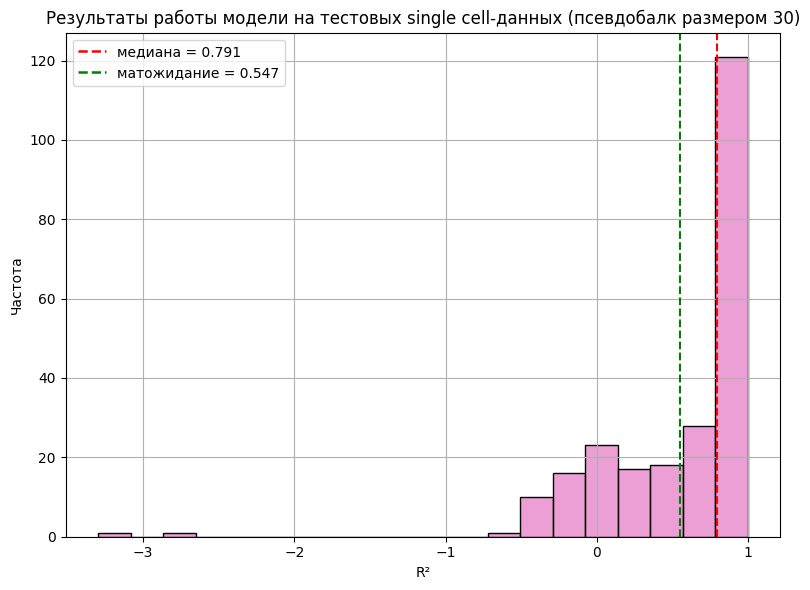

In [44]:
plot_res(df_res_new['pseudo_bulk_30'], 20, 'Результаты работы модели на тестовых single cell-данных (псевдобалк размером 30)')

0.7908252121062624

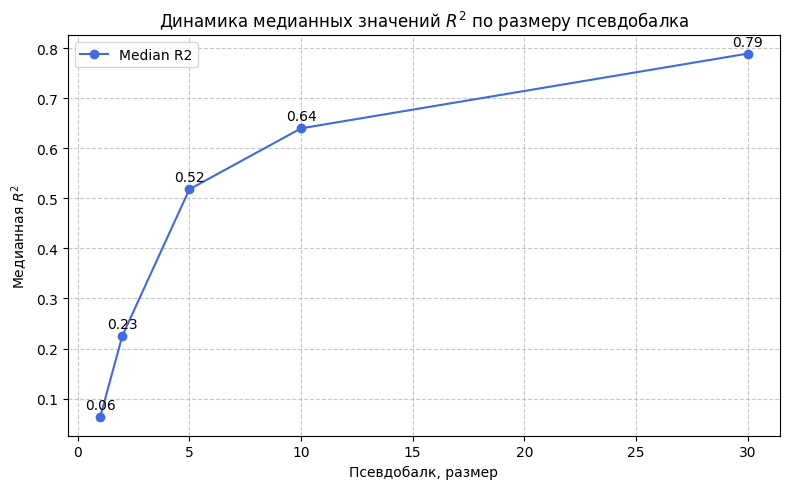

In [268]:
# Пример данных
sizes = [1, 2, 5, 10, 30]             # размеры псевдобалков
r2_medians = [df_res_new['single cell'].median(), df_res_new['pseudo_bulk_2'].median(), df_res_new['pseudo_bulk_5'].median(), df_res_new['pseudo_bulk_10'].median(), df_res_new['pseudo_bulk_30'].median()]   # медианные R2

plt.figure(figsize=(8,5))
plt.plot(sizes, r2_medians, marker='o', linestyle='-', color='royalblue', label='Median R2')

# Подписи значений у каждой точки
for x, y in zip(sizes, r2_medians):
    plt.text(x, y + 0.01, f"{y:.2f}", ha='center', va='bottom', fontsize=10, color='black')

plt.xlabel('Псевдобалк, размер')
plt.ylabel('Медианная $R^2$')
plt.title('Динамика медианных значений $R^2$ по размеру псевдобалка')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.savefig("dynamics_r2.jpg",bbox_inches="tight", transparent=True, dpi=300)
plt.show()

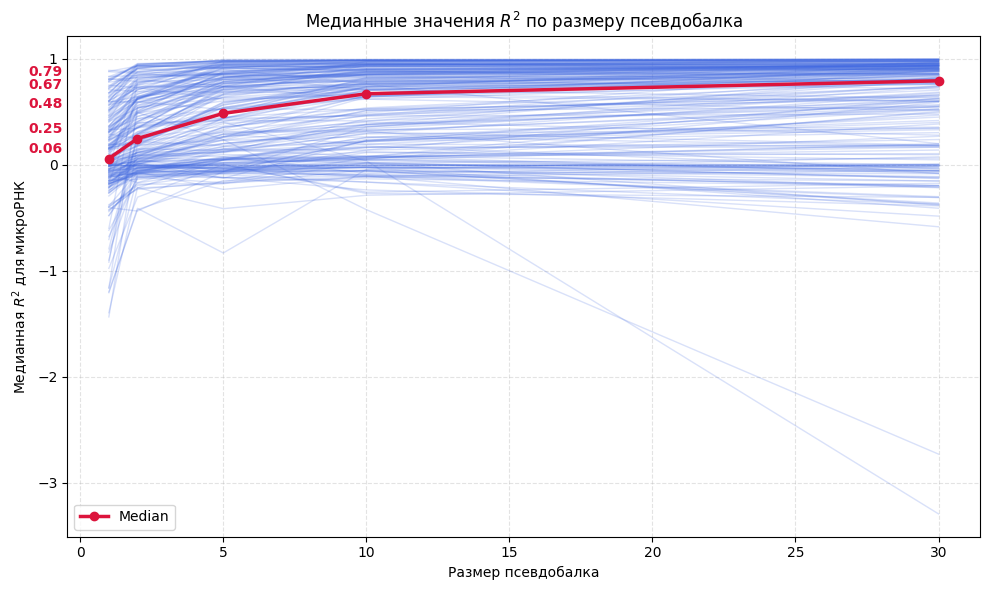

In [67]:
r2_values = np.vstack([df_res_new['single cell'].to_numpy(), 
           df_res_new['pseudo_bulk_2'].to_numpy(), 
           df_res_new['pseudo_bulk_5'].to_numpy(), 
           df_res_new['pseudo_bulk_10'].to_numpy(), 
           df_res_new['pseudo_bulk_30'].to_numpy()]).T
bulks = [1, 2, 5, 10, 30]  # размеры псевдобалков

median = [df_res_new['single cell'].median(), df_res_new['pseudo_bulk_2'].median(), df_res_new['pseudo_bulk_5'].median(), df_res_new['pseudo_bulk_10'].median(), df_res_new['pseudo_bulk_30'].median()]   # медианные R2

plt.figure(figsize=(10, 6))

# Все individual кривые
for i in range(r2_values.shape[0]):
    plt.plot(bulks, r2_values[i], color='royalblue', alpha=0.20, linewidth=1)

# Медианная траектория
plt.plot(bulks, median, color='crimson', linewidth=2.5, label='Median', marker='o')

# Подписи медианных значений только над точками
for x, y in zip(bulks, median):
    plt.text(-1.2, y + 0.02, f"{y:.2f}", ha='center', va='bottom', color='crimson', fontsize=10, fontweight='bold')

plt.xlabel('Размер псевдобалка')
plt.ylabel('Медианная $R^2$ для микроРНК')
plt.title('Медианные значения $R^2$ по размеру псевдобалка')
plt.grid(alpha=0.35, linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig("dynamics_r2_threads.jpg",bbox_inches="tight", transparent=True, dpi=300)
plt.show()

## MIR in ss

In [ ]:
## X_bulk = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_17409.parquet')  
y_bulk = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/feature_selection/y_bulk_236.parquet')

In [109]:
## import sys
sys.path.append('/mnt/jack-5/amismailov/miRNA_study')
from bootstrap import Bootstrap
path_mrna = '/mnt/jack-5/amismailov/miRNA_study/single_cell/mRNA_counts.csv'
path_mir = '/mnt/jack-5/amismailov/miRNA_study/single_cell/miRNA_counts.csv'
path_barcodes = '/mnt/jack-5/amismailov/miRNA_study/single_cell/barcodes_combined_filtered.csv' 
path_length = '/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet'

T293_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/T293_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
A549_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/A549_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
HELA_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/HELA_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
K562_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/K562_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()

boot = Bootstrap(path_mrna, path_mir, path_barcodes, path_length, selected_mirs=y_bulk.index.tolist())
tissue_types = ['293T-MS', 'A549-MS', 'HELA-MS', 'K562-MS']

In [110]:
## vars=[]
for k in [1, 2, 5, 10, 30, 50, 100, 250, 500]:
    _, y = boot.generate(tissue_types[0], K=k, N=50)
    var = y.var(axis=1).sum()
    vars.append(var)

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_vars_single(variances, K_values, title: str, logy: bool = False,
                     annotate: bool = True):
    """
    Plot variance vs K for an aggregated miRNA set (single axis, no legend/labels on points).

    Parameters
    ----------
    variances : array-like of float
        Vector of variances corresponding to each K.
    K_values : array-like of int/float
        Vector of K values (same length as variances).
    title : str
        Figure title to display.
    logy : bool, default False
        If True, use logarithmic scale for the y-axis.
    annotate : bool, default True
        If True, annotate each point with its K value.
    """
    variances = np.asarray(variances, dtype=float)
    K_values = np.asarray(K_values)

    if variances.ndim != 1 or K_values.ndim != 1:
        raise ValueError("Expected 1D arrays for 'variances' and 'K_values'.")

    if variances.shape[0] != K_values.shape[0]:
        raise ValueError("Length mismatch: 'variances' and 'K_values' must have the same length.")

    # Отсортируем по K, чтобы линия и заливка строились корректно
    order = np.argsort(K_values)
    K_values = K_values[order]
    variances = variances[order]

    sns.set_style("ticks")
    sns.set_context("talk")

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.plot(
        K_values,
        variances,
        color='tab:blue',
        linewidth=2.2,
        marker='o',
        markersize=3.5,
        markerfacecolor='white',
        markeredgewidth=1.2,
        zorder=3
    )

    # Надежная заливка: между кривой и 0 по оси Y
    ax.fill_between(
        K_values,
        variances,
        0,
        color='tab:blue',
        alpha=0.12,
        zorder=2
    )  # см. специфику fill_between [web:40][web:41]

    ax.set_xlabel('K (размер псевдобалка)')
    ax.set_ylabel('Дисперсия эксперссии микроРНК')
    ax.set_title(title)

    if logy:
        ax.set_yscale('log')

    # Подписи точек значениями K
    if annotate:
        # небольшие смещения для читаемости
        x_shift = (K_values.max() - K_values.min()) * 0.004 if K_values.size > 1 else 0.02
        y_shift = (variances.max() - variances.min()) * 0.02 if variances.max() != variances.min() else 0.02
        for x, y, k in zip(K_values, variances, K_values):
            ax.annotate(
                f'K={int(k)}' if float(k).is_integer() else f'K={k}',
                xy=(x, y),
                xytext=(x + x_shift, y + y_shift),
                textcoords='data',
                fontsize=9,
                color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7),
                zorder=4
            )  # примеры аннотаций [web:44][web:47]

    ax.grid(True, alpha=0.3, linestyle='--')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # Убедимся, что легенды нет
    lg = ax.get_legend()
    if lg is not None:
        lg.remove()

    plt.tight_layout()
    plt.savefig("single_Cell_K.jpg", bbox_inches="tight", transparent=True)
    plt.show()


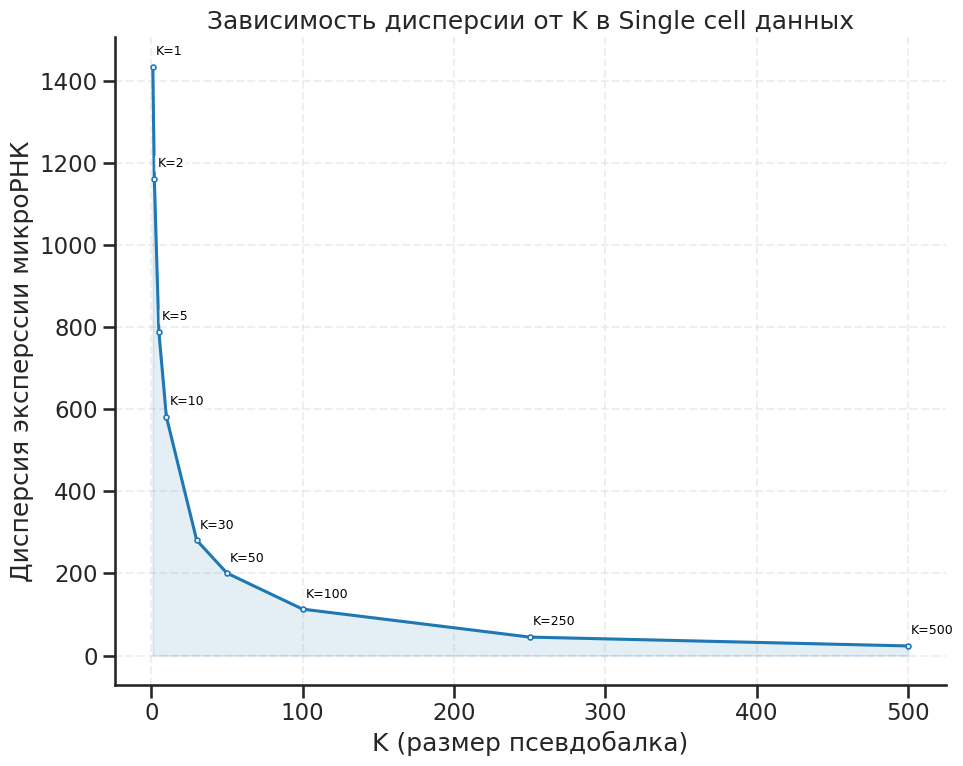

In [114]:
plot_vars_single(vars, [1, 2, 5, 10, 30, 50, 100, 250, 500], 'Зависимость дисперсии от K в Single cell данных')

In [164]:
rnas={}
mirs={}
ks = [1, 2, 5, 50]
for k in ks:
    rna_boot, mir_boot = boot.generate(tissue, K=k, N=100)
    rnas.setdefault(k, [])
    mirs.setdefault(k, [])
    rnas[k].append(rna_boot.T)
    mirs[k].append(mir_boot.T)

for k in ks:
    rnas[k] = pd.concat(rnas[k])
    mirs[k] = pd.concat(mirs[k])

In [166]:
X_ss = rnas
y_ss = mirs
'''
X_ss = []
y_ss = []
for k in [1, 2, 5]:
    x_temp=[]
    y_temp=[]
    for tissue in tissue_types:
        x, y = boot.generate(tissue, K=k, N=50)
        x_temp.append(x)
        y_temp.append(y)
    X_ss.append(pd.concat(x_temp, axis=1))
    y_ss.append(pd.concat(y_temp, axis=1))
'''

'\nX_ss = []\ny_ss = []\nfor k in [1, 2, 5]:\n    x_temp=[]\n    y_temp=[]\n    for tissue in tissue_types:\n        x, y = boot.generate(tissue, K=k, N=50)\n        x_temp.append(x)\n        y_temp.append(y)\n    X_ss.append(pd.concat(x_temp, axis=1))\n    y_ss.append(pd.concat(y_temp, axis=1))\n'

In [91]:
y.mean(axis=1)

precursor
hsa-let-7a      10.121777
hsa-let-7a-2     0.000000
hsa-let-7b       3.985270
hsa-let-7c       0.402698
hsa-let-7d       1.444245
                  ...    
hsa-mir-98       0.369180
hsa-mir-9901     0.234118
hsa-mir-9985     0.120449
hsa-mir-99a      0.602326
hsa-mir-99b     10.440278
Length: 541, dtype: float64

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_four_densities(bulk, sc, pb2, pb5,
                        labels=("1-bulk", "2-single cell", "3-pseudobulk size 2", "4-pseudobulk size 5"),
                        colors=("#1f78b4", "#33a02c", "#ff7f00", "#6a3d9a"),
                        fill=True, common_norm=False, bw_adjust=1.0, title=None, xlabel='Log2 экспрессия микроРНК'):
    """
    Строит KDE для 4 векторов одинаковой длины на одном графике.

    Parameters
    ----------
    bulk, sc, pb2, pb5 : array-like, shape (n,)
        Четыре вектора значений (например, экспрессии 236 miRNA для 4 условий).
    labels : tuple of str
        Подписи в легенде (в указанном порядке).
    colors : tuple of color
        Цвета линий/заливки.
    fill : bool
        Заполнять под кривой (полупрозрачная заливка).
    common_norm : bool
        Нормировать плотности совместно (True) или независимо (False).
    bw_adjust : float
        Коэффициент сглаживания KDE (меньше -> более «неровная» кривая, больше -> более сглаженная).
    title : str or None
        Заголовок графика.
    """
    # Приводим к numpy и проверяем размерности
    series = [np.asarray(x, dtype=float).ravel() for x in (bulk, sc, pb2, pb5)]
    n0 = series[0].size
    if not all(s.size == n0 for s in series):
        raise ValueError("Все четыре вектора должны иметь одинаковую длину.")

    sns.set_style("ticks")
    sns.set_context("talk")

    fig, ax = plt.subplots(figsize=(12, 8))
    for data, lab, col in zip(series, labels, colors):
        sns.kdeplot(
            data=data,
            ax=ax,
            fill=fill,
            color=col,
            alpha=0.25 if fill else 1.0,
            linewidth=2.0,
            bw_adjust=bw_adjust,
            common_norm=common_norm,
            label=lab,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Плотность")
    if title:
        ax.set_title(title)

    ax.legend(frameon=False, loc="best")
    ax.grid(True, linestyle="--", alpha=0.3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig("density.jpg", bbox_inches="tight", transparent=True)
    plt.show()


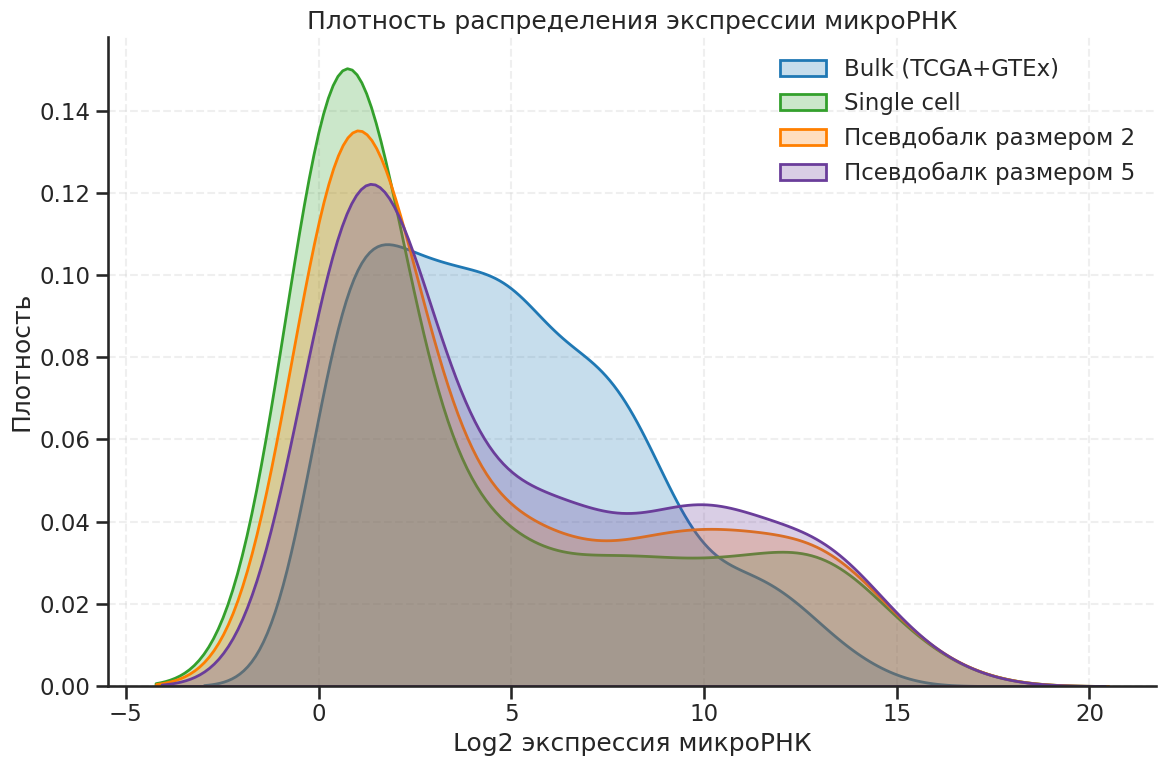

In [120]:
plot_four_densities(
    np.log2(y_bulk+1).mean(axis=1), y_ss[0].mean(axis=1), y_ss[1].mean(axis=1), y_ss[2].mean(axis=1),
    labels=("Bulk (TCGA+GTEx)", "Single cell", "Псевдобалк размером 2", "Псевдобалк размером 5"),
    colors=("#1f78b4", "#33a02c", "#ff7f00", "#6a3d9a"),
    bw_adjust=0.9,  # подстройка сглаживания
    title="Плотность распределения экспрессии микроРНК"
)

In [128]:
X_ss[0] = X_ss[0].loc[X_bulk.index]
X_ss[1] = X_ss[1].loc[X_bulk.index]
X_ss[2] = X_ss[2].loc[X_bulk.index]

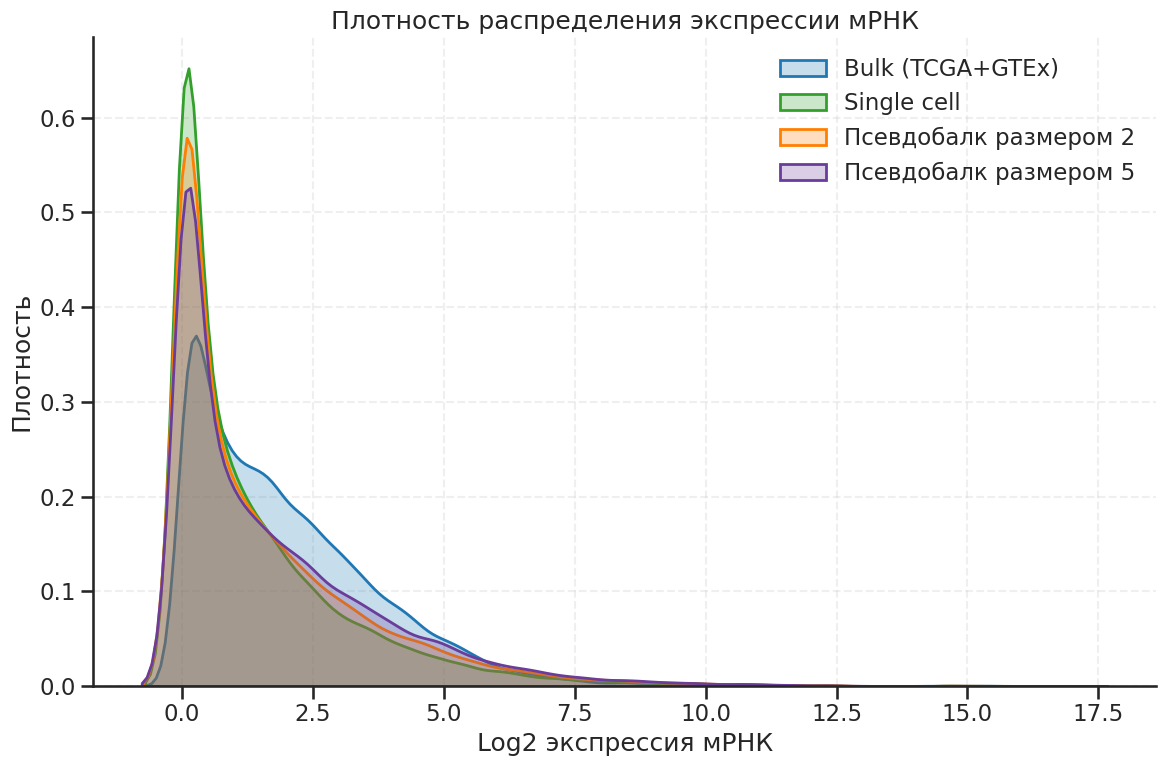

In [133]:
plot_four_densities(
    np.log2(X_bulk+1).mean(axis=1), X_ss[0].mean(axis=1), X_ss[1].mean(axis=1), X_ss[2].mean(axis=1),
    labels=("Bulk (TCGA+GTEx)", "Single cell", "Псевдобалк размером 2", "Псевдобалк размером 5"),
    colors=("#1f78b4", "#33a02c", "#ff7f00", "#6a3d9a"),
    bw_adjust=0.9,  # подстройка сглаживания
    title="Плотность распределения экспрессии мРНК", xlabel='Log2 экспрессия мРНК'
)

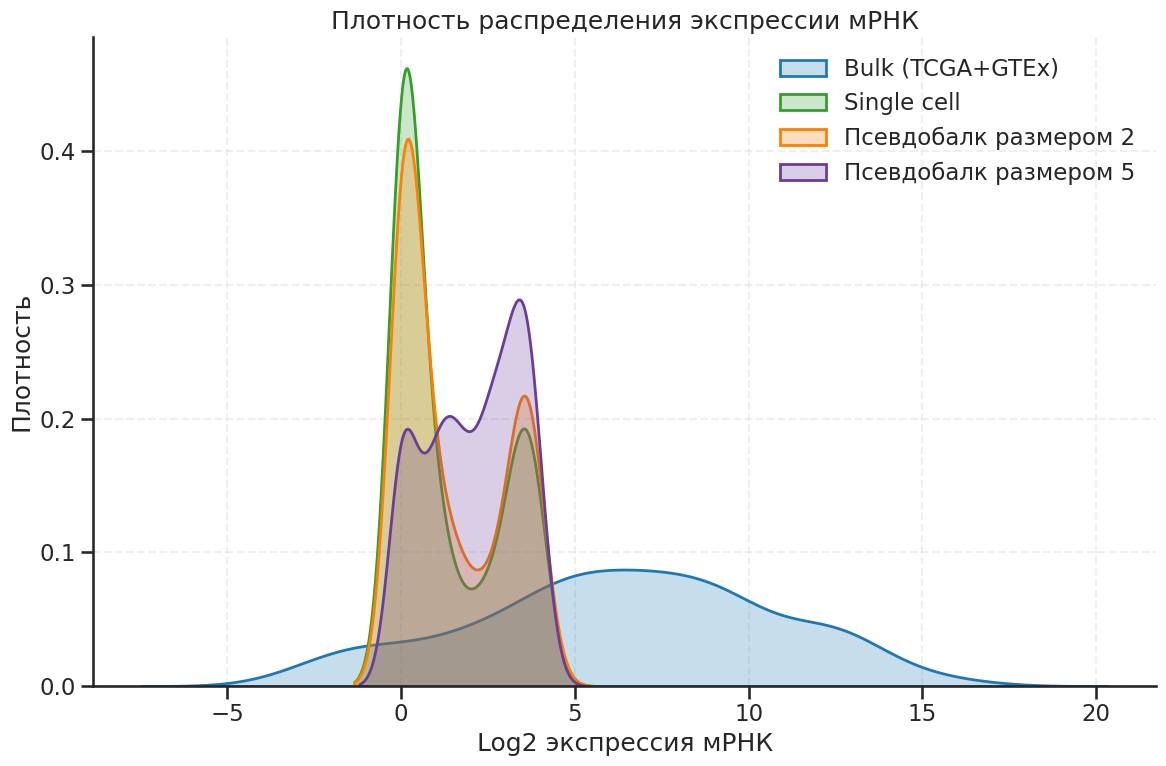

In [167]:
plot_four_densities(
    np.log2(y_bulk.mean(axis=1)), np.log2(y_ss[1].mean()+1), np.log2(y_ss[2].mean()+1), np.log2(y_ss[50].mean()+1),
    labels=("Bulk (TCGA+GTEx)", "Single cell", "Псевдобалк размером 2", "Псевдобалк размером 5"),
    colors=("#1f78b4", "#33a02c", "#ff7f00", "#6a3d9a"),
    bw_adjust=0.9,  # подстройка сглаживания
    title="Плотность распределения экспрессии мРНК", xlabel='Log2 экспрессия мРНК'
)

In [168]:
y_ss[1].mean()

precursor
hsa-let-7a-2    0.000000
hsa-let-7b      1.092246
hsa-let-7c      0.087494
hsa-let-7d      0.586484
hsa-let-7e      8.711568
                  ...   
hsa-mir-95      0.000000
hsa-mir-96      9.894026
hsa-mir-98      0.000000
hsa-mir-99a     0.000000
hsa-mir-99b     9.886827
Length: 236, dtype: float64

# FOR ALL DATASET (TRAIN/TEST)

In [72]:
top_3_mir = df_res_new[df_res_new['single cell'] > 0.85].index.tolist()

In [88]:
selected_features_df = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/feature_selection/selected_features.parquet')

In [77]:
import sys
sys.path.append('/mnt/jack-5/amismailov/miRNA_study')
from bootstrap import Bootstrap
path_mrna = '/mnt/jack-5/amismailov/miRNA_study/single_cell/mRNA_counts.csv'
path_mir = '/mnt/jack-5/amismailov/miRNA_study/single_cell/miRNA_counts.csv'
path_barcodes = '/mnt/jack-5/amismailov/miRNA_study/single_cell/barcodes_combined_filtered.csv' 
path_length = '/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet'

T293_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/T293_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
A549_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/A549_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
HELA_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/HELA_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
K562_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/K562_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()

boot = Bootstrap(path_mrna, path_mir, path_barcodes, path_length, selected_mirs=top_3_mir)
tissue_types = ['293T-MS', 'A549-MS', 'HELA-MS', 'K562-MS']

In [85]:
result=[]
for tissue in tissue_types:
    current_features
    rna_boot, _ = boot.generate(tissue, K=1, N=1000) 
    result.append(rna_boot)

N=1000 is higher than cells in sample (n=539)!
N changed to maximum available samples = 539
N=1000 is higher than cells in sample (n=625)!
N changed to maximum available samples = 625
N=1000 is higher than cells in sample (n=535)!
N changed to maximum available samples = 535
N=1000 is higher than cells in sample (n=611)!
N changed to maximum available samples = 611


In [90]:
full_dataset = pd.concat(result, axis=1).T

In [100]:
full_dataset.index

Index(['AACCAAAGGATG_1', 'AACCAAATAGAG_2', 'AACCAACCTGTT_1', 'AACCAACCTGTT_2',
       'AACCAAGAATGA_1', 'AACCTCATGTGG_1', 'AACCTCGATTAG_1', 'AACCTCGTTCTC_1',
       'AACCTCTAAGGT_2', 'AACCTCTACTCG_1',
       ...
       'TTACTTTCAGCT_2', 'TTACTTTCGCTA_1', 'TTCTGAAGGTGC_1', 'TTCTGAAGTCTT_1',
       'TTCTGAATTCAT_2', 'TTCTGACAGATT_2', 'TTCTGAGTATGC_1', 'TTCTGAGTCGTG_2',
       'TTCTGATACATC_1', 'TTCTGATTAGCC_1'],
      dtype='object', length=2310)

In [102]:
preds=[]
for mir in top_3_mir:
    data = pd.DataFrame()
    model = models[mir]
    current_features = selected_features_df[selected_features_df['mirna'] == mir]['gene'].tolist()
    current_dataset = full_dataset[current_features]
    y_pred = model.predict(current_dataset)
    y_pred = np.abs(y_pred * (y_pred > 0)) # remove negatives
    data[mir] = y_pred
    data.index = current_dataset.index
    preds.append(data)

In [112]:
all = pd.concat(preds, axis=1)

In [113]:
all['barcode'] = all.index
all.reset_index(drop=True, inplace=True)

In [114]:
all

,hsa-mir-100,hsa-mir-142,hsa-mir-335,barcode
0,0.464236,0.000000,0.000000,AACCAAAGGATG_1
1,1.947067,0.545078,0.000000,AACCAAATAGAG_2
2,9.020231,0.001610,8.394149,AACCAACCTGTT_1
3,0.223868,0.218307,0.000000,AACCAACCTGTT_2
4,0.310326,6.745037,2.445463,AACCAAGAATGA_1
...,...,...,...,...
2305,0.000000,11.221796,0.000000,TTCTGACAGATT_2
2306,1.162530,11.552386,0.584518,TTCTGAGTATGC_1
2307,0.000000,10.602030,0.000000,TTCTGAGTCGTG_2
2308,1.489910,11.317865,1.452804,TTCTGATACATC_1


In [115]:
all.to_csv('/mnt/jack-5/amismailov/miRNA_study/full/result.csv')

# GLIOBLASTOMA PREDICTION (10x)

In [272]:
gbm = pd.read_csv('//mnt/jack-5/amismailov/miRNA_study/glioblastoma/10x.csv')
gbm

,barcode,AAACCCAAGGCGATAC-1,AAACCCAAGGCTGTAG-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,...,TTTGGTTAGTGTTGAA-1,TTTGGTTGTAGGTTTC-1,TTTGGTTGTCCACATA-1,TTTGGTTGTGCTTCAA-1,TTTGGTTTCACTACGA-1,TTTGGTTTCGCTACAA-1,TTTGTTGAGGGTACGT-1,TTTGTTGCATCCGGTG-1,TTTGTTGGTCTACACA-1,TTTGTTGGTTGGTACT-1
0,MIR1302-2HG,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,FAM138A,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,OR4F5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AL627309.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AL627309.3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36596,AC141272.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36597,AC023491.2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36598,AC007325.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36599,AC007325.4,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
import pandas as pd
path_length = '/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet'
gene_lengths = pd.read_parquet(path_length)
gene_lengths

,gene_id,gene_name,gene_length_kb
0,ENSG00000142611,PRDM16,369.454
1,ENSG00000284616,None,5.467
2,ENSG00000260972,None,1.697
3,ENSG00000229280,EEF1DP6,0.372
4,ENSG00000232596,LINC01646,22.536
...,...,...,...
78894,ENSG00000307722,None,2.680
78895,ENSG00000310401,None,12.323
78896,ENSG00000302039,None,27.743
78897,ENSG00000309831,None,12.936


In [8]:
from mygene import MyGeneInfo
import pandas as pd
from tqdm import tqdm

def find_ens(list_of_genes, use_synonyms=True, verbose=False):
    """
    Конвертирует символы генов в Ensembl ID.
    При неудаче пытается найти через синонимы.
    
    Parameters:
    -----------
    list_of_genes : list
        Список символов генов
    use_synonyms : bool
        Использовать ли поиск по синонимам при неудаче (по умолчанию True)
    verbose : bool
        Выводить ли детали поиска по синонимам
        
    Returns:
    --------
    dict : {gene_symbol: ensembl_id or None}
    """
    def _search_by_synonyms(gene_symbol, mg, verbose=False):
        """
        Вспомогательная функция: ищет Ensembl ID через синонимы гена
        
        Parameters:
        -----------
        gene_symbol : str
            Символ гена, который не был найден
        mg : MyGeneInfo
            Экземпляр MyGeneInfo
        verbose : bool
            Выводить ли детальную информацию
            
        Returns:
        --------
        str or None : Ensembl gene ID или None
        """
        # Сначала получаем синонимы
        try:
            synonym_query = mg.query(
                gene_symbol,
                species='human',
                fields='symbol,alias,other_names,ensembl.gene',
                size=1
            )
            
            if not synonym_query or 'hits' not in synonym_query:
                return None
            
            hits = synonym_query['hits']
            if not hits:
                return None
            
            hit = hits[0]
            
            # Сначала проверяем, может ID есть в основном результате
            ensembl = hit.get('ensembl')
            if ensembl:
                if isinstance(ensembl, dict):
                    gene_id = ensembl.get('gene')
                    if gene_id:
                        return gene_id
                elif isinstance(ensembl, list) and len(ensembl) > 0:
                    gene_id = ensembl[0].get('gene')
                    if gene_id:
                        return gene_id
            
            # Собираем все синонимы
            aliases = []
            
            # alias может быть строкой или списком
            alias = hit.get('alias', [])
            if isinstance(alias, str):
                aliases.append(alias)
            elif isinstance(alias, list):
                aliases.extend(alias)
            
            # other_names тоже может быть строкой или списком
            other_names = hit.get('other_names', [])
            if isinstance(other_names, str):
                aliases.append(other_names)
            elif isinstance(other_names, list):
                aliases.extend(other_names)
            
            # Убираем дубликаты и исходный символ
            aliases = list(set(aliases))
            aliases = [a for a in aliases if a != gene_symbol]
            
            if not aliases:
                return None
            
            if verbose:
                print(f"  {gene_symbol} → синонимы: {aliases[:5]}...")
            
            # Пробуем искать по каждому синониму
            for syn in aliases:
                syn_query = mg.query(
                    syn,
                    scopes='symbol',
                    fields='ensembl.gene',
                    species='human',
                    size=1
                )
                
                if syn_query and 'hits' in syn_query and syn_query['hits']:
                    ensembl_data = syn_query['hits'][0].get('ensembl')
                    
                    if isinstance(ensembl_data, dict):
                        gene_id = ensembl_data.get('gene')
                        if gene_id:
                            return gene_id
                    elif isinstance(ensembl_data, list) and len(ensembl_data) > 0:
                        gene_id = ensembl_data[0].get('gene')
                        if gene_id:
                            return gene_id
            
            return None
            
        except Exception as e:
            if verbose:
                print(f"  ⚠ Ошибка при поиске синонимов для {gene_symbol}: {e}")
            return None
    
    mg = MyGeneInfo()
    
    # 1) Первичный запрос по списку символов
    query = mg.querymany(
        list_of_genes,
        scopes='symbol',
        fields='ensembl.gene',
        species='human',
        as_dataframe=False
    )
    
    results = {}
    failed_genes = []
    
    for entry in tqdm(query, desc="Primary search"):
        sym = entry.get('query')
        ensembl = entry.get('ensembl')
        notfound = entry.get('notfound', False)
        
        gene_id = None
        
        # Парсим ensembl
        if isinstance(ensembl, dict):
            gene_id = ensembl.get('gene')
        elif isinstance(ensembl, list) and len(ensembl) > 0:
            gene_id = ensembl[0].get('gene')
        
        results[sym] = gene_id
        
        # Если не нашли, добавляем в список для поиска по синонимам
        if gene_id is None or notfound:
            failed_genes.append(sym)
    
    # 2) Поиск по синонимам для ненайденных генов
    if use_synonyms and failed_genes:
        if verbose:
            print(f"\n🔍 Поиск по синонимам для {len(failed_genes)} генов...")
        
        for gene in tqdm(failed_genes, desc="Synonym search"):
            synonym_result = _search_by_synonyms(gene, mg, verbose)
            if synonym_result:
                results[gene] = synonym_result
                if verbose:
                    print(f"  ✓ {gene} → {synonym_result}")
    
    # 3) Статистика
    found = sum(1 for v in results.values() if v is not None)
    total = len(list_of_genes)
    
    print(f"\n📊 Результаты:")
    print(f"  Найдено: {found}/{total} ({100*found/total:.1f}%)")
    print(f"  Не найдено: {total-found}")
    
    return results

In [275]:
ens=find_ens(gbm['barcode'].tolist())

querying 1-1000...done.
querying 1001-2000...done.
querying 2001-3000...done.
querying 3001-4000...done.
querying 4001-5000...done.
querying 5001-6000...done.
querying 6001-7000...done.
querying 7001-8000...done.
querying 8001-9000...done.
querying 9001-10000...done.
querying 10001-11000...done.
querying 11001-12000...done.
querying 12001-13000...done.
querying 13001-14000...done.
querying 14001-15000...done.
querying 15001-16000...done.
querying 16001-17000...done.
querying 17001-18000...done.
querying 18001-19000...done.
querying 19001-20000...done.
querying 20001-21000...done.
querying 21001-22000...done.
querying 22001-23000...done.
querying 23001-24000...done.
querying 24001-25000...done.
querying 25001-26000...done.
querying 26001-27000...done.
querying 27001-28000...done.
querying 28001-29000...done.
querying 29001-30000...done.
querying 30001-31000...done.
querying 31001-32000...done.
querying 32001-33000...done.
querying 33001-34000...done.
querying 34001-35000...done.
queryin

Synonym search:  91%|████████████████████████████████████████████▌    | 13374/14708 [1:38:14<09:17,  2.39it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [276]:
ctr = 0
for x in ens.values():
    if x is not None:
        ctr+=1
ctr

23845

{'MIR1302-2HG': None,
 'FAM138A': 'ENSG00000237613',
 'OR4F5': 'ENSG00000186092',
 'AL627309.1': None,
 'AL627309.3': None,
 'AL627309.2': None,
 'AL627309.5': None,
 'AL627309.4': None,
 'AP006222.2': None,
 'AL732372.1': None,
 'OR4F29': 'ENSG00000284733',
 'AC114498.1': None,
 'OR4F16': 'ENSG00000284662',
 'AL669831.2': None,
 'LINC01409': 'ENSG00000237491',
 'FAM87B': 'ENSG00000177757',
 'LINC01128': 'ENSG00000228794',
 'LINC00115': None,
 'FAM41C': 'ENSG00000230368',
 'AL645608.6': None,
 'AL645608.2': None,
 'AL645608.4': None,
 'LINC02593': 'ENSG00000223764',
 'SAMD11': 'ENSG00000187634',
 'NOC2L': 'ENSG00000188976',
 'KLHL17': 'ENSG00000187961',
 'PLEKHN1': 'ENSG00000187583',
 'PERM1': 'ENSG00000187642',
 'AL645608.7': None,
 'HES4': 'ENSG00000188290',
 'ISG15': 'ENSG00000187608',
 'AL645608.1': None,
 'AGRN': 'ENSG00000188157',
 'AL645608.5': None,
 'AL645608.8': None,
 'RNF223': 'ENSG00000237330',
 'C1orf159': 'ENSG00000131591',
 'AL390719.3': None,
 'LINC01342': 'ENSG0000022

In [277]:
for i in range(len(gbm)):
    curr = gbm.loc[i, 'barcode']
    replace = ens[curr]
    if replace is not None:
        gbm.loc[i, 'barcode'] = replace
    else:
        gbm.loc[i, 'barcode'] = np.nan

In [278]:
gbm.dropna(inplace=True)
gbm

,barcode,AAACCCAAGGCGATAC-1,AAACCCAAGGCTGTAG-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,...,TTTGGTTAGTGTTGAA-1,TTTGGTTGTAGGTTTC-1,TTTGGTTGTCCACATA-1,TTTGGTTGTGCTTCAA-1,TTTGGTTTCACTACGA-1,TTTGGTTTCGCTACAA-1,TTTGTTGAGGGTACGT-1,TTTGTTGCATCCGGTG-1,TTTGTTGGTCTACACA-1,TTTGTTGGTTGGTACT-1
0,ENSG00000243485,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ENSG00000237613,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000186092,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,ENSG00000284733,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12,ENSG00000284662,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36568,ENSG00000198886,17,1,40,36,18,4,7,25,51,...,32,69,29,78,17,5,11,43,289,61
36569,ENSG00000198786,2,1,10,7,12,2,3,9,23,...,7,9,12,38,4,3,3,10,105,46
36570,ENSG00000198695,0,0,1,0,1,0,0,0,0,...,0,0,1,1,0,0,0,0,2,0
36571,ENSG00000198727,14,1,26,39,22,2,1,33,75,...,38,17,36,110,5,0,11,22,122,66


In [279]:
gbm.index = gbm.pop('barcode')
gbm

,AAACCCAAGGCGATAC-1,AAACCCAAGGCTGTAG-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,AAACGAAAGTATGCAA-1,...,TTTGGTTAGTGTTGAA-1,TTTGGTTGTAGGTTTC-1,TTTGGTTGTCCACATA-1,TTTGGTTGTGCTTCAA-1,TTTGGTTTCACTACGA-1,TTTGGTTTCGCTACAA-1,TTTGTTGAGGGTACGT-1,TTTGTTGCATCCGGTG-1,TTTGTTGGTCTACACA-1,TTTGTTGGTTGGTACT-1
barcode,,,,,,,,,,,,,,,,,,,,,
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000237613,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000186092,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000284733,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000284662,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198886,17,1,40,36,18,4,7,25,51,72,...,32,69,29,78,17,5,11,43,289,61
ENSG00000198786,2,1,10,7,12,2,3,9,23,21,...,7,9,12,38,4,3,3,10,105,46
ENSG00000198695,0,0,1,0,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,2,0


In [12]:
def TPM(df, gene_lengths):
        share = sorted(list(set(df.index.tolist()) & set(gene_lengths['gene_id'].tolist())))
        # filtering main dataset
        df = df[df.index.isin(share)]
        df = df.loc[share] # sorted rows
        df = df.loc[:,sorted(df.columns.tolist())] # sorted cols
        
        # filtering gene size dataset
        gene_lengths = gene_lengths[gene_lengths['gene_id'].isin(share)]
        gene_lengths = gene_lengths.sort_values(by='gene_id') # sorted rows 

        length = gene_lengths.set_index('gene_id')['gene_length_kb']
        L = length.reindex(df.index)
        
        rpk = df.div(L, axis=0)
        scale = rpk.sum(axis=0).replace(0, np.nan)
        tpm = rpk.div(scale, axis=1) * 1e6
        tpm = tpm.fillna(0.0)
        return tpm

In [281]:
gbm_tpm = TPM(gbm, gene_lengths)

In [282]:
gbm_tpm = np.log2(gbm_tpm + 1)

In [283]:
gbm_tpm

,AAACCCAAGGCGATAC-1,AAACCCAAGGCTGTAG-1,AAACCCACAAGTCCCG-1,AAACCCACAGATGCGA-1,AAACCCACAGGTGAGT-1,AAACCCAGTCTTGCGG-1,AAACCCATCGATAACC-1,AAACGAAAGACTCAAA-1,AAACGAAAGTAATCCC-1,AAACGAAAGTATGCAA-1,...,TTTGGTTAGTGTTGAA-1,TTTGGTTGTAGGTTTC-1,TTTGGTTGTCCACATA-1,TTTGGTTGTGCTTCAA-1,TTTGGTTTCACTACGA-1,TTTGGTTTCGCTACAA-1,TTTGTTGAGGGTACGT-1,TTTGTTGCATCCGGTG-1,TTTGTTGGTCTACACA-1,TTTGTTGGTTGGTACT-1
barcode,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0.0,0.0,5.084994,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,4.357954,0.000000,0.000000,0.0,0.00000,6.102992,0.000000
ENSG00000000005,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000
ENSG00000000419,0.0,0.0,0.000000,4.687491,5.08793,0.000000,0.0,0.0,3.872517,3.451939,...,0.000000,5.077546,5.075891,3.504204,0.000000,0.000000,0.0,0.00000,0.000000,0.000000
ENSG00000000457,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000
ENSG00000000460,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000295836,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000
ENSG00000304422,0.0,0.0,0.000000,0.000000,0.00000,6.951538,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000
ENSG00000307581,0.0,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000


In [284]:
selected_features_df

,mirna,gene
0,hsa-let-7a-2,ENSG00000000003
1,hsa-let-7a-2,ENSG00000000419
2,hsa-let-7a-2,ENSG00000000457
3,hsa-let-7a-2,ENSG00000000460
4,hsa-let-7a-2,ENSG00000001036
...,...,...
1558657,hsa-mir-99b,ENSG00000285480
1558658,hsa-mir-99b,ENSG00000285891
1558659,hsa-mir-99b,ENSG00000285976
1558660,hsa-mir-99b,ENSG00000286219


In [286]:
mirs = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/full/mirs.csv')['0'].tolist()
len(mirs)

67

In [287]:
gbm_tpm = gbm_tpm.T
gbm_tpm

barcode,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000293555,ENSG00000293597,ENSG00000293621,ENSG00000293644,ENSG00000293676,ENSG00000295836,ENSG00000304422,ENSG00000307581,ENSG00000310517,ENSG00000310560
AAACCCAAGGCGATAC-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AAACCCAAGGCTGTAG-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AAACCCACAAGTCCCG-1,5.084994,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.990623
AAACCCACAGATGCGA-1,0.000000,0.0,4.687491,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AAACCCACAGGTGAGT-1,0.000000,0.0,5.087930,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCGCTACAA-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,5.913125,3.301297,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.310119
TTTGTTGAGGGTACGT-1,0.000000,0.0,0.000000,0.0,0.0,5.480275,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
TTTGTTGCATCCGGTG-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.785210
TTTGTTGGTCTACACA-1,6.102992,0.0,0.000000,0.0,0.0,0.000000,0.0,6.213458,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.616426


In [288]:
gbm_tpm = gbm_tpm.loc[:, ~gbm_tpm.columns.duplicated()]
gbm_tpm

barcode,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000293555,ENSG00000293597,ENSG00000293621,ENSG00000293644,ENSG00000293676,ENSG00000295836,ENSG00000304422,ENSG00000307581,ENSG00000310517,ENSG00000310560
AAACCCAAGGCGATAC-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AAACCCAAGGCTGTAG-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AAACCCACAAGTCCCG-1,5.084994,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.990623
AAACCCACAGATGCGA-1,0.000000,0.0,4.687491,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
AAACCCACAGGTGAGT-1,0.000000,0.0,5.087930,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCGCTACAA-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,5.913125,3.301297,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.310119
TTTGTTGAGGGTACGT-1,0.000000,0.0,0.000000,0.0,0.0,5.480275,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
TTTGTTGCATCCGGTG-1,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.785210
TTTGTTGGTCTACACA-1,6.102992,0.0,0.000000,0.0,0.0,0.000000,0.0,6.213458,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.616426


In [311]:
gbm_tpm.shape

(5398, 22657)

In [312]:
preds = []
ctr = 0
for mir in mirs:
    data = pd.DataFrame()
    model = models[mir]

    current_features = selected_features_df[selected_features_df['mirna'] == mir]['gene'].tolist()
    
    # Находим отсутствующие гены
    missing_features = list(set(current_features) - set(gbm_tpm.columns))
    
    # Создаём копию подмножеcтва, чтобы дополнить нулями недостающие гены
    current_dataset = gbm_tpm[current_features].copy() if set(current_features) <= set(gbm_tpm.columns) else gbm_tpm.reindex(columns=current_features, fill_value=0).copy()
    
    # Если были недостающие гены, заполненные нулями — можно сообщить
    if missing_features:
        print(f'For miR {mir} filled {len(missing_features)} missing mRNAs with zeroes.')
    
    y_pred = model.predict(current_dataset)
    #y_pred = np.abs(y_pred * (y_pred > 0)) # remove negatives
    data[mir] = y_pred
    data.index = current_dataset.index
    preds.append(data)


For miR hsa-let-7b filled 239 missing mRNAs with zeroes.
For miR hsa-let-7c filled 389 missing mRNAs with zeroes.
For miR hsa-let-7d filled 161 missing mRNAs with zeroes.
For miR hsa-let-7g filled 396 missing mRNAs with zeroes.
For miR hsa-let-7i filled 364 missing mRNAs with zeroes.
For miR hsa-mir-100 filled 290 missing mRNAs with zeroes.
For miR hsa-mir-106a filled 385 missing mRNAs with zeroes.
For miR hsa-mir-1271 filled 344 missing mRNAs with zeroes.
For miR hsa-mir-1301 filled 384 missing mRNAs with zeroes.
For miR hsa-mir-130a filled 416 missing mRNAs with zeroes.
For miR hsa-mir-135b filled 210 missing mRNAs with zeroes.
For miR hsa-mir-142 filled 465 missing mRNAs with zeroes.
For miR hsa-mir-144 filled 295 missing mRNAs with zeroes.
For miR hsa-mir-145 filled 260 missing mRNAs with zeroes.
For miR hsa-mir-146b filled 435 missing mRNAs with zeroes.
For miR hsa-mir-148a filled 173 missing mRNAs with zeroes.
For miR hsa-mir-148b filled 376 missing mRNAs with zeroes.
For miR hsa

In [313]:
pd.concat(preds, axis=1).to_csv('/mnt/jack-5/amismailov/miRNA_study/glioblastoma/predicted_mirs_v3.csv')

# GLIOBLASTOMA PREDICTION (smartseq)

In [291]:
gbm = pd.read_csv('//mnt/jack-5/amismailov/miRNA_study/glioblastoma/smartseq.csv')
gbm

,barcode,MGH42_P7_A01,MGH42_P7_A02,MGH42_P7_A03,MGH42_P7_A04,MGH42_P7_A05,MGH42_P7_A07,MGH42_P7_A09,MGH42_P7_A11,MGH42_P7_A12,...,MGH107neg_P2_E06,MGH107pos_P2_B03,MGH107neg_P1_F03,MGH107neg_P1_G06,MGH107neg_P2_H03,MGH107neg_P2_C05,MGH107pos_P2_D07,MGH107neg_P1_E01,MGH107pos_P2_G09,MGH107neg_P1_D06
0,A1BG,1.19280,0.000000,0.00000,0.00000,0.00000,0.66903,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2.4772,0.00000,0.0000
1,A1BG-AS1,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.83996,0.00000,0.0000,0.00000,0.0000
2,A1CF,0.00000,0.094912,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000
3,A2M,7.04390,7.609500,0.77062,7.61460,0.00000,0.00000,0.27501,8.16240,6.56550,...,0.00000,8.60460,0.00000,0.00000,0.00000,0.00000,9.52810,0.0000,6.89990,0.0000
4,A2M-AS1,0.00000,0.000000,0.00000,0.00000,2.03390,2.39420,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23681,ZYG11A,0.00000,0.370720,0.47508,0.15056,0.47508,0.26063,0.15704,0.26664,0.34483,...,0.25580,0.13225,0.50080,0.31383,0.50691,0.17505,0.13225,0.9381,0.47301,0.0000
23682,ZYG11B,0.27143,0.444670,3.13260,1.48650,4.03830,2.00580,2.73880,0.70399,0.10299,...,0.16864,0.45101,0.20414,0.45733,0.65627,2.94070,0.27739,1.9464,0.48749,4.7947
23683,ZYX,2.70580,2.107700,0.00000,3.84590,3.82720,3.21550,3.23450,3.17860,1.13420,...,3.86430,0.00000,0.00000,0.00000,2.66150,0.31383,0.00000,0.0000,0.00000,0.0000
23684,ZZEF1,0.71370,1.143400,0.00000,0.00000,1.55140,1.16220,2.32280,2.37380,0.45312,...,0.10702,0.00000,3.08370,2.23760,0.00000,1.03490,0.00000,0.0000,0.00000,1.8969


In [292]:
ens=find_ens(gbm['barcode'].tolist())

querying 1-1000...done.
querying 1001-2000...done.
querying 2001-3000...done.
querying 3001-4000...done.
querying 4001-5000...done.
querying 5001-6000...done.
querying 6001-7000...done.
querying 7001-8000...done.
querying 8001-9000...done.
querying 9001-10000...done.
querying 10001-11000...done.
querying 11001-12000...done.
querying 12001-13000...done.
querying 13001-14000...done.
querying 14001-15000...done.
querying 15001-16000...done.
querying 16001-17000...done.
querying 17001-18000...done.
querying 18001-19000...done.
querying 19001-20000...done.
querying 20001-21000...done.
querying 21001-22000...done.
querying 22001-23000...done.
querying 23001-23686...done.
Finished.
680 input query terms found dup hits:
	[('A2MP1', 2), ('AACSP1', 2), ('ABCA11P', 2), ('ABCA17P', 2), ('ABCC13', 2), ('ABCC6P1', 2), ('ABCC6
2794 input query terms found no hit:
	['AAED1', 'AARS', 'AATK-AS1', 'ABP1', 'ACN9', 'ACPL2', 'ACPP', 'ACPT', 'ACRC', 'ACTN1-AS1', 'ADAL', 
Pass "returnall=True" to return compl

Synonym search: 100%|█████████████████████████████████████████████████████| 3459/3459 [30:09<00:00,  1.91it/s]


📊 Результаты:
  Найдено: 22446/23686 (94.8%)
  Не найдено: 1240


In [295]:
for i in range(len(gbm)):
    curr = gbm.loc[i, 'barcode']
    replace = ens[curr]
    if replace is not None:
        gbm.loc[i, 'barcode'] = replace
    else:
        gbm.loc[i, 'barcode'] = np.nan
gbm.dropna(inplace=True)
gbm

,barcode,MGH42_P7_A01,MGH42_P7_A02,MGH42_P7_A03,MGH42_P7_A04,MGH42_P7_A05,MGH42_P7_A07,MGH42_P7_A09,MGH42_P7_A11,MGH42_P7_A12,...,MGH107neg_P2_E06,MGH107pos_P2_B03,MGH107neg_P1_F03,MGH107neg_P1_G06,MGH107neg_P2_H03,MGH107neg_P2_C05,MGH107pos_P2_D07,MGH107neg_P1_E01,MGH107pos_P2_G09,MGH107neg_P1_D06
0,ENSG00000121410,1.19280,0.000000,0.00000,0.00000,0.00000,0.66903,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,2.4772,0.00000,0.0000
1,ENSG00000268895,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.83996,0.00000,0.0000,0.00000,0.0000
2,ENSG00000148584,0.00000,0.094912,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000
3,ENSG00000175899,7.04390,7.609500,0.77062,7.61460,0.00000,0.00000,0.27501,8.16240,6.56550,...,0.00000,8.60460,0.00000,0.00000,0.00000,0.00000,9.52810,0.0000,6.89990,0.0000
4,ENSG00000245105,0.00000,0.000000,0.00000,0.00000,2.03390,2.39420,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23681,ENSG00000203995,0.00000,0.370720,0.47508,0.15056,0.47508,0.26063,0.15704,0.26664,0.34483,...,0.25580,0.13225,0.50080,0.31383,0.50691,0.17505,0.13225,0.9381,0.47301,0.0000
23682,ENSG00000162378,0.27143,0.444670,3.13260,1.48650,4.03830,2.00580,2.73880,0.70399,0.10299,...,0.16864,0.45101,0.20414,0.45733,0.65627,2.94070,0.27739,1.9464,0.48749,4.7947
23683,ENSG00000159840,2.70580,2.107700,0.00000,3.84590,3.82720,3.21550,3.23450,3.17860,1.13420,...,3.86430,0.00000,0.00000,0.00000,2.66150,0.31383,0.00000,0.0000,0.00000,0.0000
23684,ENSG00000074755,0.71370,1.143400,0.00000,0.00000,1.55140,1.16220,2.32280,2.37380,0.45312,...,0.10702,0.00000,3.08370,2.23760,0.00000,1.03490,0.00000,0.0000,0.00000,1.8969


In [296]:
gbm.sort_values(by='barcode', inplace=True)

In [297]:
gbm.index = gbm.pop('barcode')

In [298]:
gbm = gbm.T
gbm.drop('55872', axis=1, inplace=True)
gbm

barcode,126231,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000300109,ENSG00000300194,ENSG00000303991,ENSG00000304422,ENSG00000304501,ENSG00000309702,ENSG00000310537,ENSG00000310560,ENSG00000310576,ENSG00000310585
MGH42_P7_A01,0.00000,0.0000,0.0,0.0000,0.00000,0.0000,4.5947,0.0,3.45440,0.0000,...,2.15570,0.0,0.0000,0.0000,0.0,0.00000,0.0000,2.3028,1.2179,0.0
MGH42_P7_A02,0.00000,0.0000,0.0,4.5082,0.00000,0.0000,0.0000,0.0,0.00000,4.1196,...,0.44784,0.0,0.0000,0.0000,0.0,0.79992,0.0000,0.0000,1.3016,0.0
MGH42_P7_A03,0.00000,0.0000,0.0,0.0000,0.24975,3.2251,0.0000,0.0,0.28451,0.0000,...,0.69421,0.0,0.0000,4.0018,0.0,0.00000,0.0000,0.0000,0.0000,0.0
MGH42_P7_A04,0.00000,0.0000,0.0,0.0000,0.00000,0.0000,5.8163,0.0,4.47490,0.0000,...,0.00000,0.0,0.0000,0.0000,0.0,0.00000,0.0000,0.0000,3.4155,0.0
MGH42_P7_A05,0.00000,0.0000,0.0,5.5461,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,...,2.99200,0.0,0.0000,0.0000,0.0,0.00000,0.0000,4.8139,4.1823,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MGH107neg_P2_C05,6.50760,0.0000,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,...,2.25430,0.0,3.7550,0.0000,0.0,0.00000,0.0000,0.0000,3.1635,0.0
MGH107pos_P2_D07,0.00000,0.0000,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,...,0.85917,0.0,0.0000,0.0000,0.0,0.00000,3.0179,0.0000,0.0000,0.0
MGH107neg_P1_E01,0.00000,3.6562,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,3.2065,...,0.00000,0.0,0.0000,4.6280,0.0,0.00000,0.0000,0.0000,0.0000,0.0
MGH107pos_P2_G09,0.19912,0.0000,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,...,0.27977,0.0,0.0000,0.0000,0.0,0.00000,0.0000,5.4079,5.6336,0.0


In [300]:
gbm.drop('126231', axis=1, inplace=True)

/mnt/jack-1/tmp/ipykernel_609374/309675404.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gbm.drop('126231', axis=1, inplace=True)


In [301]:
gbm = gbm.loc[:, ~gbm.columns.duplicated()]
gbm

barcode,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000300109,ENSG00000300194,ENSG00000303991,ENSG00000304422,ENSG00000304501,ENSG00000309702,ENSG00000310537,ENSG00000310560,ENSG00000310576,ENSG00000310585
MGH42_P7_A01,0.0000,0.0,0.0000,0.00000,0.0000,4.5947,0.0,3.45440,0.0000,0.0000,...,2.15570,0.0,0.0000,0.0000,0.0,0.00000,0.0000,2.3028,1.2179,0.0
MGH42_P7_A02,0.0000,0.0,4.5082,0.00000,0.0000,0.0000,0.0,0.00000,4.1196,0.0000,...,0.44784,0.0,0.0000,0.0000,0.0,0.79992,0.0000,0.0000,1.3016,0.0
MGH42_P7_A03,0.0000,0.0,0.0000,0.24975,3.2251,0.0000,0.0,0.28451,0.0000,0.0000,...,0.69421,0.0,0.0000,4.0018,0.0,0.00000,0.0000,0.0000,0.0000,0.0
MGH42_P7_A04,0.0000,0.0,0.0000,0.00000,0.0000,5.8163,0.0,4.47490,0.0000,0.0000,...,0.00000,0.0,0.0000,0.0000,0.0,0.00000,0.0000,0.0000,3.4155,0.0
MGH42_P7_A05,0.0000,0.0,5.5461,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,0.0000,...,2.99200,0.0,0.0000,0.0000,0.0,0.00000,0.0000,4.8139,4.1823,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MGH107neg_P2_C05,0.0000,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,2.0423,...,2.25430,0.0,3.7550,0.0000,0.0,0.00000,0.0000,0.0000,3.1635,0.0
MGH107pos_P2_D07,0.0000,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,0.0000,...,0.85917,0.0,0.0000,0.0000,0.0,0.00000,3.0179,0.0000,0.0000,0.0
MGH107neg_P1_E01,3.6562,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,3.2065,0.0000,...,0.00000,0.0,0.0000,4.6280,0.0,0.00000,0.0000,0.0000,0.0000,0.0
MGH107pos_P2_G09,0.0000,0.0,0.0000,0.00000,0.0000,0.0000,0.0,0.00000,0.0000,0.0000,...,0.27977,0.0,0.0000,0.0000,0.0,0.00000,0.0000,5.4079,5.6336,0.0


In [302]:
gbm = np.log2(gbm+1)

In [314]:
preds = []
ctr = 0
for mir in mirs:
    data = pd.DataFrame()
    model = models[mir]
    current_features = selected_features_df[selected_features_df['mirna'] == mir]['gene'].tolist()
    
    # Находим отсутствующие гены
    missing_features = list(set(current_features) - set(gbm.columns))
    
    # Создаём копию подмножеcтва, чтобы дополнить нулями недостающие гены
    current_dataset = gbm[current_features].copy() if set(current_features) <= set(gbm.columns) else gbm.reindex(columns=current_features, fill_value=0).copy()
    
    # Если были недостающие гены, заполненные нулями — можно сообщить
    if missing_features:
        print(f'For miR {mir} filled {len(missing_features)} missing mRNAs with zeroes.')
    
    y_pred = model.predict(current_dataset)
    #y_pred = np.abs(y_pred * (y_pred > 0)) # remove negatives
    data[mir] = y_pred
    data.index = current_dataset.index
    preds.append(data)


For miR hsa-let-7b filled 287 missing mRNAs with zeroes.
For miR hsa-let-7c filled 518 missing mRNAs with zeroes.
For miR hsa-let-7d filled 234 missing mRNAs with zeroes.
For miR hsa-let-7g filled 521 missing mRNAs with zeroes.
For miR hsa-let-7i filled 494 missing mRNAs with zeroes.
For miR hsa-mir-100 filled 407 missing mRNAs with zeroes.
For miR hsa-mir-106a filled 521 missing mRNAs with zeroes.
For miR hsa-mir-1271 filled 445 missing mRNAs with zeroes.
For miR hsa-mir-1301 filled 483 missing mRNAs with zeroes.
For miR hsa-mir-130a filled 523 missing mRNAs with zeroes.
For miR hsa-mir-135b filled 289 missing mRNAs with zeroes.
For miR hsa-mir-142 filled 617 missing mRNAs with zeroes.
For miR hsa-mir-144 filled 387 missing mRNAs with zeroes.
For miR hsa-mir-145 filled 360 missing mRNAs with zeroes.
For miR hsa-mir-146b filled 580 missing mRNAs with zeroes.
For miR hsa-mir-148a filled 220 missing mRNAs with zeroes.
For miR hsa-mir-148b filled 501 missing mRNAs with zeroes.
For miR hsa

In [315]:
pd.concat(preds, axis=1).to_csv('/mnt/jack-5/amismailov/miRNA_study/glioblastoma/smartseq_mirs_v3.csv')

In [305]:
preds

[                  hsa-let-7b
 MGH42_P7_A01       -5.284023
 MGH42_P7_A02       -3.982468
 MGH42_P7_A03       -3.748160
 MGH42_P7_A04       -4.411545
 MGH42_P7_A05       -4.665998
 ...                      ...
 MGH107neg_P2_C05   -6.942103
 MGH107pos_P2_D07   -8.276463
 MGH107neg_P1_E01   -8.090046
 MGH107pos_P2_G09   -6.951450
 MGH107neg_P1_D06   -7.636354
 
 [6341 rows x 1 columns],
                   hsa-let-7c
 MGH42_P7_A01       -0.714274
 MGH42_P7_A02       -0.122423
 MGH42_P7_A03       -0.393043
 MGH42_P7_A04       -0.607437
 MGH42_P7_A05       -0.760094
 ...                      ...
 MGH107neg_P2_C05   -0.370484
 MGH107pos_P2_D07   -0.849135
 MGH107neg_P1_E01   -0.364740
 MGH107pos_P2_G09   -0.890980
 MGH107neg_P1_D06   -0.550440
 
 [6341 rows x 1 columns],
                   hsa-let-7d
 MGH42_P7_A01       -1.612450
 MGH42_P7_A02       -2.330019
 MGH42_P7_A03       -0.192323
 MGH42_P7_A04       -1.829990
 MGH42_P7_A05       -1.527517
 ...                      ...
 MGH107neg_P2_

## LUNG

In [1]:
import pandas as pd

In [2]:
import sys, os

module_dir = "/mnt/jack-5/amismailov/miRNA_study"  # тут полный путь к папке
sys.path.append(module_dir)

In [3]:
import importlib, preprocessor
importlib.reload(preprocessor)

from preprocessor import SingleCell

In [4]:
sc = SingleCell()

In [5]:
luad = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/lung/raw/td1.csv')
luad

,barcode,AAACCCAAGACCTTTG-1,AAACCCAAGCCTGAAG-1,AAACCCAAGCTGTGCC-1,AAACCCAAGGCCACTC-1,AAACCCAAGGGTTAAT-1,AAACCCAAGTCGAATA-1,AAACCCAAGTTCCTGA-1,AAACCCACAACACGAG-1,AAACCCACAGTCAGAG-1,...,TTTGTTGAGTCAGAGC-1,TTTGTTGAGTCATGAA-1,TTTGTTGCAAACGTGG-1,TTTGTTGCACGTAGTT-1,TTTGTTGCAGAACTAA-1,TTTGTTGCAGGACTTT-1,TTTGTTGCATGTGGCC-1,TTTGTTGGTAGAATGT-1,TTTGTTGGTATTGAGA-1,TTTGTTGGTTCGGTCG-1
0,AL627309.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AL669831.5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,FAM87B,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,LINC00115,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,FAM41C,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21375,AC007325.2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21376,AL354822.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21377,AC004556.1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
21378,AC233755.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
luad = sc.replace_genes_names(luad)

Try to find ENS for all genes...
querying 1-1000...done.
querying 1001-2000...done.
querying 2001-3000...done.
querying 3001-4000...done.
querying 4001-5000...done.
querying 5001-6000...done.
querying 6001-7000...done.
querying 7001-8000...done.
querying 8001-9000...done.
querying 9001-10000...done.
querying 10001-11000...done.
querying 11001-12000...done.
querying 12001-13000...done.
querying 13001-14000...done.
querying 14001-15000...done.
querying 15001-16000...done.
querying 16001-17000...done.
querying 17001-18000...done.
querying 18001-19000...done.
querying 19001-20000...done.
querying 20001-21000...done.
querying 21001-21380...done.
Finished.
456 input query terms found dup hits:
	[('LINC00115', 2), ('SLC35E2A', 2), ('TNFRSF14-AS1', 3), ('CAMTA1-DT', 2), ('SLC25A34-AS1', 2), ('LI
4189 input query terms found no hit:
	['AL627309.1', 'AL669831.5', 'AL645608.3', 'AL645608.1', 'AL645608.8', 'AL645608.9', 'AL390719.2', '
Pass "returnall=True" to return complete lists of duplicate or

Synonym search: 100%|██████████████████████| 4613/4613 [33:13<00:00,  2.31it/s]



📊 Результаты:
  Найдено: 17802/21380 (83.3%)
  Не найдено: 3578
Replacing 21380 genes...
Finish: 17802 genes replaced


In [7]:
luad = luad[2:]
luad

,AAACCCAAGACCTTTG-1,AAACCCAAGCCTGAAG-1,AAACCCAAGCTGTGCC-1,AAACCCAAGGCCACTC-1,AAACCCAAGGGTTAAT-1,AAACCCAAGTCGAATA-1,AAACCCAAGTTCCTGA-1,AAACCCACAACACGAG-1,AAACCCACAGTCAGAG-1,AAACCCAGTCGCGTCA-1,...,TTTGTTGAGTCAGAGC-1,TTTGTTGAGTCATGAA-1,TTTGTTGCAAACGTGG-1,TTTGTTGCACGTAGTT-1,TTTGTTGCAGAACTAA-1,TTTGTTGCAGGACTTT-1,TTTGTTGCATGTGGCC-1,TTTGTTGGTAGAATGT-1,TTTGTTGGTATTGAGA-1,TTTGTTGGTTCGGTCG-1
barcode,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,0,1,0,1,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0
ENSG00000000457,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000460,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000938,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000295836,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000310517,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000310517,0,3,0,0,0,0,0,1,0,1,...,1,0,0,0,1,0,0,0,1,0


In [8]:
luad_tpm = sc.TPM(luad)

Совпадение генов: 17071/17718


In [10]:
preds = sc.predict(luad_tpm.T)

Prediction of miRNAs expression..


  0%|                                                  | 0/236 [00:00<?, ?it/s]

For miR hsa-let-7a-2 filled 778 missing mRNAs with zeroes.


  0%|▏                                         | 1/236 [00:00<03:39,  1.07it/s]

For miR hsa-let-7b filled 403 missing mRNAs with zeroes.


...

 99%|███████████████████████████████████████▋| 234/236 [02:32<00:01,  1.29it/s]

For miR hsa-mir-99a filled 902 missing mRNAs with zeroes.


100%|███████████████████████████████████████▊| 235/236 [02:33<00:00,  1.26it/s]

For miR hsa-mir-99b filled 602 missing mRNAs with zeroes.


100%|████████████████████████████████████████| 236/236 [02:34<00:00,  1.53it/s]


In [11]:
preds.to_csv('/mnt/jack-5/amismailov/miRNA_study/lung/td1_mirs.csv')

### within clusters

In [12]:
clusters = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/lung/raw/cell_clusters.csv')

In [13]:
bacrode_dict = {}
for cluster in list(clusters['cluster'].unique()):
    bacrode_dict.setdefault(cluster, None)
    bacrode_dict[cluster] = clusters[clusters['cluster'] == cluster]['barcode'].tolist()

In [14]:
cluster_df = pd.DataFrame()
for cluster in list(clusters['cluster'].unique()):
    curr = luad[bacrode_dict[cluster]].sum(axis=1)
    cluster_df[cluster] = curr

In [15]:
cluster_df

,CD4 naive T cells,Ciliated cells,CD8 T cells,Monocytes,exhausted T cells,AT1,Plasmacytes,Malignant cells,B lymphocytes,Mast cells,Macrophages,Tregs,Cycling T cells,AT2,NK-cells,Fibroblasts,Dendritic cells,Endothelial cells
barcode,,,,,,,,,,,,,,,,,,
ENSG00000000003,8,158,9,10,2,6,4,759,2,8,9,0,0,68,1,28,2,15
ENSG00000000419,248,43,311,196,99,15,109,722,60,60,119,81,25,161,49,82,102,27
ENSG00000000457,24,10,28,15,11,3,10,74,7,3,15,6,7,20,9,13,4,2
ENSG00000000460,14,0,18,19,4,0,3,104,7,2,8,6,4,7,2,6,4,0
ENSG00000000938,2,4,33,194,0,1,6,11,21,15,200,1,0,2,40,7,111,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000295836,4,3,5,2,2,1,2,224,1,2,0,1,0,12,0,3,0,3
ENSG00000310517,0,0,0,2,0,0,0,1,0,0,1,0,0,0,0,0,0,0
ENSG00000310517,702,333,857,651,190,62,189,2568,223,363,578,340,28,580,256,237,179,105


In [16]:
cluster_df = sc.TPM(cluster_df)

Совпадение генов: 17071/17718


In [18]:
preds = sc.predict(cluster_df)

Prediction of miRNAs expression..


  0%|                                                  | 0/236 [00:00<?, ?it/s]

For miR hsa-let-7a-2 filled 9628 missing mRNAs with zeroes.


  0%|▏                                         | 1/236 [00:01<05:47,  1.48s/it]

For miR hsa-let-7b filled 5305 missing mRNAs with zeroes.


...

 99%|███████████████████████████████████████▋| 234/236 [04:14<00:02,  1.29s/it]

For miR hsa-mir-99a filled 9304 missing mRNAs with zeroes.


100%|███████████████████████████████████████▊| 235/236 [04:16<00:01,  1.35s/it]

For miR hsa-mir-99b filled 8639 missing mRNAs with zeroes.


100%|████████████████████████████████████████| 236/236 [04:17<00:00,  1.09s/it]


In [183]:
preds

,hsa-let-7a-2,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7g,hsa-let-7i,hsa-mir-100,hsa-mir-103a-1,hsa-mir-106a,...,hsa-mir-887,hsa-mir-889,hsa-mir-92a-1,hsa-mir-92b,hsa-mir-93,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
CD4 naive T cells,14.817998,12.169334,5.198116,9.112398,10.042958,7.595619,8.670043,8.852348,16.068821,8.190561,...,0.607031,2.624459,6.572049,7.254052,12.929133,4.372490,3.310616,4.518106,3.225474,9.664891
Ciliated cells,11.404417,14.362048,5.784264,9.916574,7.992652,8.979435,7.565443,12.223641,11.755247,7.566955,...,5.020680,2.523347,6.565409,8.626222,12.189407,6.817904,6.201297,5.700430,6.122462,10.530104
CD8 T cells,13.707664,12.394473,4.739742,9.548528,9.305335,8.601046,7.980968,9.110837,16.437706,7.756021,...,1.450512,2.608616,7.360380,6.811130,13.426764,4.512961,2.780804,4.207860,3.894848,9.197938
Monocytes,13.766735,12.950643,6.935868,10.316479,9.027319,9.239313,8.028968,10.712600,15.431622,6.342000,...,0.450744,2.652750,8.209606,8.111568,12.573050,3.103004,2.779618,4.664111,6.624041,9.447263
exhausted T cells,13.929749,12.428082,4.157849,9.329847,9.177898,9.258429,7.710714,9.412809,16.119650,7.928340,...,1.734413,2.508226,6.556587,7.353897,13.588856,3.673655,4.061404,2.704121,2.800174,8.984920
AT1,13.479985,13.755764,5.783698,10.546518,7.772393,9.362702,8.207496,11.858079,11.712728,5.981612,...,1.873487,3.168521,3.986090,7.418242,12.671154,7.479254,5.659431,5.984226,3.516687,12.391044
Plasmacytes,13.285039,8.891472,6.300519,10.604736,9.046674,10.762859,10.514443,7.544097,13.601768,3.280823,...,1.393732,0.705542,11.397916,7.736217,13.646897,0.334904,1.673692,6.777766,3.812055,9.566898
Malignant cells,9.110566,13.409461,5.951956,9.035843,10.184572,8.364455,6.659673,11.639130,10.291357,7.050201,...,1.642518,3.093734,7.326918,9.760096,12.406544,3.733432,5.101147,7.163216,8.398176,10.533184
B lymphocytes,10.284573,11.944072,4.412914,8.861516,8.259278,9.752106,8.031487,8.664712,10.475788,9.464318,...,0.587008,2.868503,7.731432,8.523801,12.927715,4.026998,3.237200,5.286141,4.202533,8.894757
Mast cells,11.027055,14.047019,5.348025,10.125226,8.868176,10.551689,7.921783,8.541194,10.830232,8.500299,...,1.518709,2.665548,7.837174,7.192327,13.186868,4.049021,3.115991,3.700496,4.603577,10.252746


In [22]:
preds.index.tolist()

['ENSG00000000003',
 'ENSG00000000419',
 'ENSG00000000457',
 'ENSG00000000460',
 'ENSG00000000938',
 'ENSG00000000971',
 'ENSG00000001036',
 'ENSG00000001084',
 'ENSG00000001167',
 'ENSG00000001460',
 'ENSG00000001461',
 'ENSG00000001497',
 'ENSG00000001561',
 'ENSG00000001617',
 'ENSG00000001626',
 'ENSG00000001629',
 'ENSG00000001630',
 'ENSG00000001631',
 'ENSG00000002016',
 'ENSG00000002330',
 'ENSG00000002549',
 'ENSG00000002586',
 'ENSG00000002587',
 'ENSG00000002726',
 'ENSG00000002745',
 'ENSG00000002746',
 'ENSG00000002822',
 'ENSG00000002834',
 'ENSG00000002919',
 'ENSG00000002933',
 'ENSG00000003056',
 'ENSG00000003096',
 'ENSG00000003137',
 'ENSG00000003147',
 'ENSG00000003249',
 'ENSG00000003393',
 'ENSG00000003400',
 'ENSG00000003402',
 'ENSG00000003436',
 'ENSG00000003509',
 'ENSG00000003756',
 'ENSG00000003987',
 'ENSG00000003989',
 'ENSG00000004059',
 'ENSG00000004139',
 'ENSG00000004142',
 'ENSG00000004399',
 'ENSG00000004455',
 'ENSG00000004468',
 'ENSG00000004478',


In [19]:
preds_full = []

for cluster in clusters['cluster'].unique():
    curr_preds = preds.loc[cluster]                         # Series (miRNA)
    barcodes = bacrode_dict[cluster]                       # список баркодов
    # создаём матрицу miRNA × клетки внутри кластера
    block = pd.DataFrame({bc: curr_preds for bc in barcodes})
    preds_full.append(block)

preds_full = pd.concat(preds_full, axis=1)

KeyError: 'CD4 naive T cells'

In [185]:
preds_full.T.to_csv('/mnt/jack-5/amismailov/miRNA_study/lung/td1_mirs_clusters.csv')

# LUNG2

In [93]:
luad = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/lung/raw/td2.csv')
luad

,barcode,AAACCCAAGGCTAACG-1,AAACCCACAACACGTT-1,AAACCCACAATCTAGC-1,AAACCCACACAGCGCT-1,AAACCCACACATGGTT-1,AAACCCACACGGTGAA-1,AAACCCACAGATAAAC-1,AAACCCACAGGCATGA-1,AAACCCACAGGGATAC-1,...,TTTGTTGCAAGGTCTT-1,TTTGTTGCACCAACAT-1,TTTGTTGCATCGATGT-1,TTTGTTGGTCTGTGGC-1,TTTGTTGGTGATTCAC-1,TTTGTTGGTTCGTAAC-1,TTTGTTGGTTGTGGAG-1,TTTGTTGTCACCATGA-1,TTTGTTGTCAGCATTG-1,TTTGTTGTCATGGTAC-1
0,AL627309.1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AL669831.5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,FAM87B,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,LINC00115,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,FAM41C,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20877,AC007325.2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20878,AL354822.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20879,AC004556.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20880,AC233755.2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [94]:
luad = sc.replace_genes_names(luad)

Try to find ENS for all genes...
querying 1-1000...done.
querying 1001-2000...done.
querying 2001-3000...done.
querying 3001-4000...done.
querying 4001-5000...done.
querying 5001-6000...done.
querying 6001-7000...done.
querying 7001-8000...done.
querying 8001-9000...done.
querying 9001-10000...done.
querying 10001-11000...done.
querying 11001-12000...done.
querying 12001-13000...done.
querying 13001-14000...done.
querying 14001-15000...done.
querying 15001-16000...done.
querying 16001-17000...done.
querying 17001-18000...done.
querying 18001-19000...done.
querying 19001-20000...done.
querying 20001-20882...done.
Finished.
424 input query terms found dup hits:
	[('LINC00115', 2), ('LINC01786', 2), ('SLC35E2A', 2), ('TNFRSF14-AS1', 3), ('CAMTA1-DT', 2), ('LINC0
3959 input query terms found no hit:
	['AL627309.1', 'AL669831.5', 'AL645608.1', 'AL645608.8', 'AL645608.9', 'AL390719.2', 'AL162741.1', '
Pass "returnall=True" to return complete lists of duplicate or missing query terms.


Synonym search: 100%|███████████████████████| 4351/4351 [31:58<00:00,  2.27it/s]



📊 Результаты:
  Найдено: 17512/20882 (83.9%)
  Не найдено: 3370
Replacing 20882 genes...
Finish: 17512 genes replaced


In [ ]:
#luad = luad[2:]
luad

In [95]:
luad_tpm = sc.TPM(luad)

Совпадение генов: 16804/17434


In [96]:
preds = sc.predict(luad_tpm.T)

Prediction of miRNAs expression..


  0%|                                                   | 0/236 [00:00<?, ?it/s]

For miR hsa-let-7a-2 filled 839 missing mRNAs with zeroes.


  0%|▏                                          | 1/236 [00:01<06:05,  1.55s/it]

For miR hsa-let-7b filled 435 missing mRNAs with zeroes.


...

 99%|████████████████████████████████████████▋| 234/236 [04:29<00:03,  1.64s/it]

For miR hsa-mir-99a filled 977 missing mRNAs with zeroes.


100%|████████████████████████████████████████▊| 235/236 [04:31<00:01,  1.77s/it]

For miR hsa-mir-99b filled 636 missing mRNAs with zeroes.


100%|█████████████████████████████████████████| 236/236 [04:32<00:00,  1.16s/it]


In [97]:
preds

,hsa-let-7a-2,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7g,hsa-let-7i,hsa-mir-100,hsa-mir-103a-1,hsa-mir-106a,...,hsa-mir-887,hsa-mir-889,hsa-mir-92a-1,hsa-mir-92b,hsa-mir-93,hsa-mir-95,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
AAACCCAAGGCTAACG-1,6.574698,5.676985,2.378233,4.552432,6.015153,6.315881,7.706484,3.724984,7.131026,5.571211,...,2.241312,0.993633,12.155902,7.363772,12.600484,1.233277,1.310547,2.684351,5.561759,10.369401
AAACCCACAACACGTT-1,5.194681,3.328357,3.771417,6.074212,6.804027,9.076762,5.892540,4.247630,6.620500,5.380715,...,0.800494,0.280406,10.698032,6.925216,12.528299,0.767787,1.801237,3.056389,7.591164,11.262503
AAACCCACAATCTAGC-1,5.695010,4.399703,2.467246,2.408341,5.197604,5.921342,5.753849,1.441445,6.587030,4.836665,...,0.877381,0.650576,6.518506,7.709897,12.375820,1.072170,1.947789,0.413243,7.390223,10.973984
AAACCCACACAGCGCT-1,6.380136,9.020411,5.319636,4.908791,7.112278,7.831799,6.227034,4.897516,6.407563,5.473361,...,0.540911,0.434220,8.731796,7.953628,12.373960,1.481402,2.634536,1.244578,6.903857,10.651484
AAACCCACACATGGTT-1,5.260708,3.619106,3.043566,3.094920,6.964046,4.676575,5.677317,2.265219,6.724084,4.766269,...,1.137987,0.499317,8.920311,6.850072,12.697628,1.054853,2.490942,1.333248,8.665408,11.107510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTTCGTAAC-1,4.591918,3.599036,3.308304,2.376125,6.959575,5.435499,5.358258,2.019738,6.636694,4.706429,...,0.967768,0.189422,6.888746,7.798348,12.783655,0.695893,1.571230,1.176923,4.978374,9.952194
TTTGTTGGTTGTGGAG-1,6.770370,5.830766,4.554882,4.767631,4.594965,5.326644,5.479255,1.853388,7.107610,4.142318,...,1.510552,0.967076,7.310606,7.712786,12.705857,1.431503,1.200626,2.079037,8.563470,9.674207
TTTGTTGTCACCATGA-1,5.577765,4.104113,2.735368,3.506573,5.366904,5.334390,2.318363,3.491782,7.141318,5.407390,...,0.624088,0.346114,9.967675,7.629765,12.023073,0.962218,1.676771,0.196668,7.355103,10.499103
TTTGTTGTCAGCATTG-1,6.205241,2.867705,2.064162,2.269945,7.394632,4.543484,6.594195,1.797181,7.402292,4.837686,...,1.433257,0.647081,8.961177,6.747700,11.409940,3.315225,1.672418,1.884778,8.764587,10.398038


In [98]:
preds.to_csv('/mnt/jack-5/amismailov/miRNA_study/lung/td2_mirs.csv')

### within clusters

In [99]:
clusters = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/lung/raw/cell_clusters_td2.csv')

In [100]:
bacrode_dict = {}
for cluster in list(clusters['cluster'].unique()):
    bacrode_dict.setdefault(cluster, None)
    bacrode_dict[cluster] = clusters[clusters['cluster'] == cluster]['barcode'].tolist()

In [101]:
cluster_df = pd.DataFrame()
for cluster in list(clusters['cluster'].unique()):
    curr = luad[bacrode_dict[cluster]].sum(axis=1)
    cluster_df[cluster] = curr

In [102]:
cluster_df = sc.TPM(cluster_df)

Совпадение генов: 16804/17434


In [105]:
preds = sc.predict(cluster_df.T)

Prediction of miRNAs expression..


  0%|                                                   | 0/236 [00:00<?, ?it/s]

For miR hsa-let-7a-2 filled 839 missing mRNAs with zeroes.


  0%|▏                                          | 1/236 [00:00<03:09,  1.24it/s]

For miR hsa-let-7b filled 435 missing mRNAs with zeroes.


...

 99%|████████████████████████████████████████▋| 234/236 [01:52<00:01,  1.92it/s]

For miR hsa-mir-99a filled 977 missing mRNAs with zeroes.


100%|████████████████████████████████████████▊| 235/236 [01:53<00:00,  1.66it/s]

For miR hsa-mir-99b filled 636 missing mRNAs with zeroes.


100%|█████████████████████████████████████████| 236/236 [01:53<00:00,  2.07it/s]


In [106]:
preds_full = []

for cluster in clusters['cluster'].unique():
    curr_preds = preds.loc[cluster]                         # Series (miRNA)
    barcodes = bacrode_dict[cluster]                       # список баркодов
    # создаём матрицу miRNA × клетки внутри кластера
    block = pd.DataFrame({bc: curr_preds for bc in barcodes})
    preds_full.append(block)

preds_full = pd.concat(preds_full, axis=1)

In [107]:
preds_full.T.to_csv('/mnt/jack-5/amismailov/miRNA_study/lung/td2_mirs_clusters.csv')

# LUNG9

In [66]:
luad = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/lung/raw/td9.csv')
luad

,barcode,AAACCCAAGACTACGG-1,AAACCCAAGACTCGAG-1,AAACCCAAGAGAAGGT-1,AAACCCAAGATACAGT-1,AAACCCAAGTTGAAGT-1,AAACCCAAGTTGAATG-1,AAACCCAGTAACCAGG-1,AAACCCAGTACCTAAC-1,AAACCCAGTATGGTTC-1,...,TTTGTTGCAAATGAGT-1,TTTGTTGCACCGGAAA-1,TTTGTTGCACTAGGTT-1,TTTGTTGCATCGTGGC-1,TTTGTTGGTTAGGCTT-1,TTTGTTGGTTCAGCTA-1,TTTGTTGTCAGATTGC-1,TTTGTTGTCAGCAGAG-1,TTTGTTGTCTATCCAT-1,TTTGTTGTCTGCCTCA-1
0,AL627309.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AL669831.5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,FAM87B,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,LINC00115,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,FAM41C,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21718,AC007325.2,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
21719,AL354822.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21720,AC233755.2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21721,AC233755.1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [67]:
luad = sc.replace_genes_names(luad)

Try to find ENS for all genes...
querying 1-1000...done.
querying 1001-2000...done.
querying 2001-3000...done.
querying 3001-4000...done.
querying 4001-5000...done.
querying 5001-6000...done.
querying 6001-7000...done.
querying 7001-8000...done.
querying 8001-9000...done.
querying 9001-10000...done.
querying 10001-11000...done.
querying 11001-12000...done.
querying 12001-13000...done.
querying 13001-14000...done.
querying 14001-15000...done.
querying 15001-16000...done.
querying 16001-17000...done.
querying 17001-18000...done.
querying 18001-19000...done.
querying 19001-20000...done.
querying 20001-21000...done.
querying 21001-21723...done.
Finished.
465 input query terms found dup hits:
	[('LINC00115', 2), ('LINC01786', 2), ('SLC35E2A', 2), ('TNFRSF14-AS1', 3), ('CAMTA1-DT', 2), ('LINC0
4519 input query terms found no hit:
	['AL627309.1', 'AL669831.5', 'AL645608.3', 'AL645608.1', 'AL645608.8', 'AL645608.9', 'AL390719.2', '
Pass "returnall=True" to return complete lists of duplicate or

Synonym search: 100%|███████████████████████| 4963/4963 [36:51<00:00,  2.24it/s]



📊 Результаты:
  Найдено: 17808/21723 (82.0%)
  Не найдено: 3915
Replacing 21723 genes...
Finish: 17808 genes replaced


In [68]:
luad = luad[2:]
luad

,AAACCCAAGACTACGG-1,AAACCCAAGACTCGAG-1,AAACCCAAGAGAAGGT-1,AAACCCAAGATACAGT-1,AAACCCAAGTTGAAGT-1,AAACCCAAGTTGAATG-1,AAACCCAGTAACCAGG-1,AAACCCAGTACCTAAC-1,AAACCCAGTATGGTTC-1,AAACCCAGTCTGTGCG-1,...,TTTGTTGCAAATGAGT-1,TTTGTTGCACCGGAAA-1,TTTGTTGCACTAGGTT-1,TTTGTTGCATCGTGGC-1,TTTGTTGGTTAGGCTT-1,TTTGTTGGTTCAGCTA-1,TTTGTTGTCAGATTGC-1,TTTGTTGTCAGCAGAG-1,TTTGTTGTCTATCCAT-1,TTTGTTGTCTGCCTCA-1
barcode,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,0,0,0,0,0,0,0,1,4,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,0,0,0,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,1,0,0
ENSG00000000457,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000460,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000938,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000295836,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
ENSG00000310517,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000310517,0,0,0,0,1,2,0,0,2,0,...,3,0,2,1,0,1,0,0,0,0


In [69]:
luad_tpm = sc.TPM(luad)

Совпадение генов: 17069/17724


In [70]:
preds = sc.predict(luad_tpm.T)

Prediction of miRNAs expression..


  0%|                                                   | 0/236 [00:00<?, ?it/s]

For miR hsa-let-7a-2 filled 793 missing mRNAs with zeroes.


  0%|▏                                          | 1/236 [00:01<07:06,  1.82s/it]

For miR hsa-let-7b filled 420 missing mRNAs with zeroes.


...

 99%|████████████████████████████████████████▋| 234/236 [04:19<00:02,  1.42s/it]

For miR hsa-mir-99a filled 953 missing mRNAs with zeroes.


100%|████████████████████████████████████████▊| 235/236 [04:20<00:01,  1.33s/it]

For miR hsa-mir-99b filled 635 missing mRNAs with zeroes.


100%|█████████████████████████████████████████| 236/236 [04:22<00:00,  1.11s/it]


In [71]:
preds.to_csv('/mnt/jack-5/amismailov/miRNA_study/lung/td9_mirs.csv')

### within clusters (TD9)

In [76]:
clusters = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/lung/raw/cell_clusters_td9.csv')

In [77]:
clusters

,barcode,cluster
0,AAACCCAAGACTACGG-1,Naive T cells
1,AAACCCAAGACTCGAG-1,Monocytes
2,AAACCCAAGAGAAGGT-1,Naive T cells
3,AAACCCAAGATACAGT-1,B lymphocytes
4,AAACCCAAGTTGAAGT-1,Monocytes
...,...,...
16317,TTTGTTGGTTCAGCTA-1,B lymphocytes
16318,TTTGTTGTCAGATTGC-1,Macrophages
16319,TTTGTTGTCAGCAGAG-1,Malingnant
16320,TTTGTTGTCTATCCAT-1,Monocytes


In [25]:
bacrode_dict = {}
for cluster in list(clusters['cluster'].unique()):
    bacrode_dict.setdefault(cluster, None)
    bacrode_dict[cluster] = clusters[clusters['cluster'] == cluster]['barcode'].tolist()

In [26]:
cluster_df = pd.DataFrame()
for cluster in list(clusters['cluster'].unique()):
    curr = luad[bacrode_dict[cluster]].sum(axis=1)
    cluster_df[cluster] = curr

In [27]:
cluster_df

,CD4 naive T cells,Ciliated cells,CD8 T cells,Monocytes,exhausted T cells,AT1,Plasmacytes,Malignant cells,B lymphocytes,Mast cells,Macrophages,Tregs,Cycling T cells,AT2,NK-cells,Fibroblasts,Dendritic cells,Endothelial cells
barcode,,,,,,,,,,,,,,,,,,
ENSG00000000003,8,158,9,10,2,6,4,759,2,8,9,0,0,68,1,28,2,15
ENSG00000000419,248,43,311,196,99,15,109,722,60,60,119,81,25,161,49,82,102,27
ENSG00000000457,24,10,28,15,11,3,10,74,7,3,15,6,7,20,9,13,4,2
ENSG00000000460,14,0,18,19,4,0,3,104,7,2,8,6,4,7,2,6,4,0
ENSG00000000938,2,4,33,194,0,1,6,11,21,15,200,1,0,2,40,7,111,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000295836,4,3,5,2,2,1,2,224,1,2,0,1,0,12,0,3,0,3
ENSG00000310517,0,0,0,2,0,0,0,1,0,0,1,0,0,0,0,0,0,0
ENSG00000310517,702,333,857,651,190,62,189,2568,223,363,578,340,28,580,256,237,179,105


In [28]:
cluster_df = sc.TPM(cluster_df)

Совпадение генов: 17071/17718


In [29]:
preds = sc.predict(cluster_df.T)

Prediction of miRNAs expression..


  0%|                                                  | 0/236 [00:00<?, ?it/s]

For miR hsa-let-7a-2 filled 778 missing mRNAs with zeroes.


  1%|▎                                         | 2/236 [00:00<01:43,  2.26it/s]

For miR hsa-let-7b filled 403 missing mRNAs with zeroes.
For miR hsa-let-7c filled 744 missing mRNAs with zeroes.


...

 99%|███████████████████████████████████████▋| 234/236 [01:49<00:01,  1.82it/s]

For miR hsa-mir-99a filled 902 missing mRNAs with zeroes.


100%|███████████████████████████████████████▊| 235/236 [01:49<00:00,  1.69it/s]

For miR hsa-mir-99b filled 602 missing mRNAs with zeroes.


100%|████████████████████████████████████████| 236/236 [01:50<00:00,  2.14it/s]


In [30]:
preds_full = []

for cluster in clusters['cluster'].unique():
    curr_preds = preds.loc[cluster]                         # Series (miRNA)
    barcodes = bacrode_dict[cluster]                       # список баркодов
    # создаём матрицу miRNA × клетки внутри кластера
    block = pd.DataFrame({bc: curr_preds for bc in barcodes})
    preds_full.append(block)

preds_full = pd.concat(preds_full, axis=1)

In [87]:
preds_full.T.to_csv('/mnt/jack-5/amismailov/miRNA_study/lung/td9_mirs_clusters.csv')

In [13]:
df.shape

(343, 35664)

In [1]:
import pandas as pd
df = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/merged/merged_expanded_miR.csv', index_col=0)

In [4]:
selected_features_df = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/feature_selection/selected_features.parquet')
mirs = list(selected_features_df['mirna'].unique())

In [7]:
df.mean(axis=1)

hsa-let-7a-2     6492.758437
hsa-let-7b      15922.397348
hsa-let-7c       1496.162464
hsa-let-7d       1386.053464
hsa-let-7e        798.429447
                    ...     
hsa-mir-95        366.393990
hsa-mir-96         28.045071
hsa-mir-98        739.271281
hsa-mir-99a     44205.271946
hsa-mir-99b     15404.698432
Length: 343, dtype: float64

/mnt/jack-1/tmp/ipykernel_33155/2264330639.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


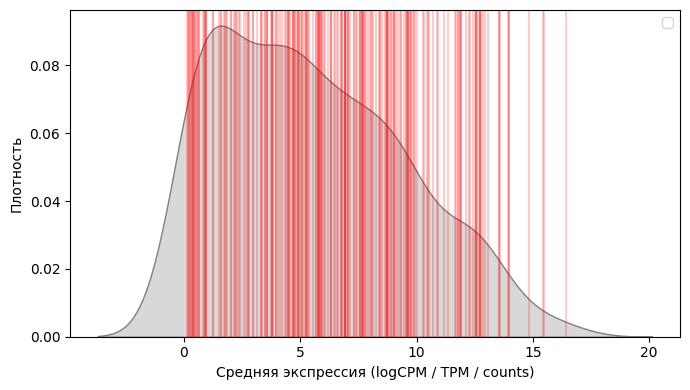

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Средняя экспрессия по образцам
mean_expr = np.log2(df.mean(axis=1)+1)  # Series: index = miRNA, values = mean

# 2. Флаг принадлежности к сабсету
mirs_set = set(mirs)
is_subset = mean_expr.index.to_series().isin(mirs_set)

# 3а. Вариант 1: KDE + точки для сабсета
plt.figure(figsize=(7, 4))
sns.kdeplot(mean_expr, fill=True, alpha=0.3, color="grey")  # общая дистрибуция

# точки сабсета на оси X
# вертикальные линии для сабсета
for v in subset_vals:
    plt.axvline(v, color="red", alpha=0.2)

plt.xlabel("Средняя экспрессия (logCPM / TPM / counts)")
plt.ylabel("Плотность")
#plt.title("Распределение средних экспрессий miRNA\nс подсветкой сабсета")
plt.legend()
plt.tight_layout()
plt.show()


# generation of ss test dataset

In [61]:
import sys
from tqdm import tqdm

sys.path.append('/mnt/jack-5/amismailov/miRNA_study')
from bootstrap import Bootstrap_v2
 
selected_features_df = pq.read_table('/mnt/jack-5/amismailov/miRNA_study/feature_selection/selected_features.parquet').to_pandas()
features = selected_features_df['gene'].unique()
targets = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/learning/targets.csv', index_col=0)['miR'].tolist()


def ss_collector():
    T293_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/T293_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
    A549_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/A549_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
    HELA_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/HELA_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
    K562_test_barcodes = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/single_cell/train_test_split/K562_specific_barcodes_test.csv',index_col=0)['barcode'].tolist()
   
    zip_test = zip([T293_test_barcodes, A549_test_barcodes, HELA_test_barcodes, K562_test_barcodes], 
                ['293T-MS', 'A549-MS', 'HELA-MS', 'K562-MS'])
    rnas={}
    mirs={}
    ks = [1, 2, 5, 10, 30]

    boot = Bootstrap_v2(path_mrna, path_mir, path_barcodes, path_length, selected_rna=features, selected_mirs=targets)
    ctr=1
    for bars, tissue in zip_test:
        print(f'Tissue: {tissue}... {ctr}/{4}')
        ctr+=1
        for k in tqdm(ks):
            rna_boot, mir_boot = boot.generate(bars, tissue, K=k, N=100)
             
            rnas.setdefault(k, [])
            mirs.setdefault(k, [])
            rnas[k].append(rna_boot)
            mirs[k].append(mir_boot)
    
    for k in ks:
        rnas[k] = pd.concat(rnas[k], axis=1)
        mirs[k] = pd.concat(mirs[k], axis=1)

    return (rnas, mirs)

In [62]:
res = ss_collector()

Tissue: 293T-MS... 1/4


100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  3.26it/s]


Tissue: A549-MS... 2/4


100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  3.16it/s]


Tissue: HELA-MS... 3/4


100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  3.18it/s]


Tissue: K562-MS... 4/4


100%|█████████████████████████████████████████████| 5/5 [00:02<00:00,  2.41it/s]


In [77]:
features_ind = 0
targets_ind = 1
ks = [1, 2, 5, 10, 30]
for k in ks:
    res[features_ind][k].to_csv(f'/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/test_data/ss_test_k{k}_features.csv')
    res[targets_ind][k].to_csv(f'/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/single_cell_datasets/test_data/ss_test_k{k}_targets.csv')